# Project Description: Telecommunications

Telecom operator TeleDom wants to combat customer churn. To do this, its employees will begin offering promo codes and special deals to anyone planning to cancel their telecom service. To identify such users in advance, TeleDom needs a model that can predict whether a subscriber will cancel their contract. The operator's team has collected personal data on some customers, as well as information about their plans and services.

**Description of services**


1. The operator provides two main types of services:

    1) Landline telephone service. A telephone can be connected to several lines simultaneously.
    
    2) Internet. The connection can be of two types: via a telephone line (DSL) or a fiber optic cable (Fiber optic).


2. The following services are also available:

    1) Internet security: antivirus (DeviceProtection) and blocking of unsafe websites (OnlineSecurity);
    
    2) Dedicated technical support line (TechSupport);
    
    3) Cloud file storage for data backup (OnlineBackup);
    
    4) Streaming TV and movie catalog (Streaming Movies).

Clients can pay monthly or sign a one- to two-year contract. Payment options include a variety of payment methods and electronic receipts.

**Task**

Train a model to predict customer churn using this data.

**Plan**

1. Data loading
2. Exploratory analysis and data preprocessing
3. Data merging
4. Exploratory analysis and data preprocessing of the merged dataframe
5. Data preparation
6. Training machine learning models
7. Selecting the best model
8. Overall conclusion and recommendations to the client

In [1]:
!pip install shap -q
!pip install optuna-integration[sklearn] -q
!pip install phik -q
!pip install -U scikit-learn
!pip install xgboost


     |████████████████████████████████| 13.5 MB 2.1 MB/s eta 0:00:01
     |████████████████████████████████| 308 kB 73.0 MB/s eta 0:00:01
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.1
    Uninstalling scikit-learn-0.24.1:
      Successfully uninstalled scikit-learn-0.24.1


Checking versions

In [2]:
import os
import re
import warnings
warnings.filterwarnings('ignore')
import shap
import phik
import optuna


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin


from sklearn.model_selection import cross_val_score, StratifiedKFold
#from sklearn.inspection import permutation_importance

from sklearn.metrics import (
                    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score,
                    classification_report, roc_curve, auc
)
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier



RANDOM_STATE = 171125
TEST_SIZE = 0.25


In [3]:
# Function of analysis of quantitative and categorical features
def analyze_numeric(df, col):
    print(f'Feature analysis: {col}')
    display(df[col].describe())
    print('Gaps:', df[col].isna().sum())
    n = df[col].dropna().shape[0]
    bins = int(np.log2(n) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)  
    df[col].hist(bins=bins, edgecolor='k')
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.subplot(1, 2, 2)
    df.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.ylabel('Frequency')
    plt.show()

# Function of analysis of quantitative discrete features
def analyze_discrete_feature(df, column):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column, palette='Set2')
    plt.title(f'Distribution of feature values "{column}"')
    plt.xlabel(column)
    plt.ylabel('Quantity')
    plt.grid(True, axis='y')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    freq_table = df[column].value_counts().sort_index()
    percent_table = round(df[column].value_counts(normalize=True).sort_index() * 100, 2)

    result = pd.DataFrame({
        'Meaning': freq_table.index,
        'Frequency': freq_table.values,
        'Share (%)': percent_table.values
    })

    return result



def analyze_categorical(df, col):
    print(f'Feature analysis: {col}')
    print('Unique:', df[col].nunique())
    print('Gaps:', df[col].isna().sum())
    display(df[col].value_counts(dropna=False))
    df[col].value_counts(dropna=False).plot(
        kind='bar', figsize=(8, 4), edgecolor='k')
    plt.title(f"Distribution: {col}")
    plt.ylabel('Frequency')
    plt.xlabel(col)
    plt.show()

## Loading data


In [4]:
path1 = ['/datasets/contract_new.csv', '/datasets/personal_new.csv', '/datasets/internet_new.csv',
        '/datasets/phone_new.csv']

path2 = ['C:/Users/maxim/Downloads/contract_new.csv', 'C:/Users/maxim/Downloads/personal_new.csv',
        'C:/Users/maxim/Downloads/internet_new.csv', 'C:/Users/maxim/Downloads/phone_new.csv']


# select the current set of paths
if all(os.path.exists(p) for p in path1):
    paths = path1
elif all(os.path.exists(p) for p in path2):
    paths = path2
else:
    raise FileNotFoundError("Не удалось найти все необходимые файлы")

#if all(os.path.exists(p) for p in path1):
#    paths = path1
#else:
  #  print('Something is wrong')

contract_new_df = pd.read_csv(paths[0], delimiter = ',', encoding = 'utf-8')
personal_new_df = pd.read_csv(paths[1], delimiter = ',', encoding = 'utf-8')
internet_new_df = pd.read_csv(paths[2], delimiter = ',', encoding = 'utf-8')
phone_new_df = pd.read_csv(paths[3], delimiter = ',', encoding = 'utf-8')

In [5]:
tables_lists = [contract_new_df, personal_new_df, internet_new_df, phone_new_df]

for t in tables_lists:
    display(t.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [6]:
for t in tables_lists:
    display(t.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


None

In [7]:
for t in tables_lists:
    display(t.describe())

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


,SeniorCitizen
count,7043.000000
mean,0.162147
std,0.368612
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
count,5517,5517,5517,5517,5517,5517,5517,5517
unique,5517,2,2,2,2,2,2,2
top,1352-VHKAJ,Fiber optic,No,No,No,No,No,No
freq,1,3096,3498,3088,3095,3473,2810,2785


,customerID,MultipleLines
count,6361,6361
unique,6361,2
top,3523-BRGUW,No
freq,1,3390


### Primary data analysis

1) Number of rows and columns:

- contract_new_df: 7043 rows, 8 columns
- personal_new_df: 7043 rows, 5 columns
- internet_new_df: 5517 rows, 8 columns
- phone_new_df: 6361 rows, 2 columns



2) No gaps found.

3) The name must be converted to camel_case format.

4) Not all data types match the description.
    BeginDate, EndDate - must be converted to date format
    SeniorCitizen - here it is assumed that 0 is no and 1 is yes.
    MonthlyCharges, TotalCharges - need to be converted to float format.
    
5) We can check for duplicates in the Type, PaymentMethod, gender, and InternetService columns.

Most clients (approximately 75%) are not retirees, meaning the audience is relatively young. The distribution of monthly payments is skewed to the left: many clients are on cheaper plans and far fewer are on more expensive ones. Moreover, most clients do not subscribe to additional services, which may indicate both high costs and insufficient communication of the value of these services. To increase subscriptions, promotional offers (such as a discount or a free first month) can be tested to lower the barrier to entry and demonstrate the true value of the services to clients.

## Exploratory analysis and data preprocessing

In [8]:
pd.crosstab(internet_new_df['InternetService'], internet_new_df['OnlineSecurity'], normalize='index')

OnlineSecurity,No,Yes
InternetService,,
DSL,0.512598,0.487402
Fiber optic,0.729005,0.270995


In [9]:
for col in ['OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingTV']:
    display(col)
    display(pd.crosstab(internet_new_df['InternetService'], internet_new_df[col], normalize='index'))


'OnlineSecurity'

OnlineSecurity,No,Yes
InternetService,,
DSL,0.512598,0.487402
Fiber optic,0.729005,0.270995


'OnlineBackup'

OnlineBackup,No,Yes
InternetService,,
DSL,0.551425,0.448575
Fiber optic,0.566214,0.433786


'TechSupport'

TechSupport,No,Yes
InternetService,,
DSL,0.513424,0.486576
Fiber optic,0.720284,0.279716


'StreamingTV'

StreamingTV,No,Yes
InternetService,,
DSL,0.604709,0.395291
Fiber optic,0.434755,0.565245



- A comparison of the behavior of DSL and Fiber optic clients shows that OnlineBackup is used approximately equally in both groups, meaning that this service is universal and does not depend on the type of Internet.

- At the same time, Fiber optic customers are significantly less likely to have OnlineSecurity and TechSupport enabled: approximately 70% of users opt out of these services, which is logically explained by Fiber's higher base price—customers are cutting back on additional expenses.

- At the same time, the StreamingTV service is most often connected to Fiber Optic, since its use directly depends on the connection speed, and the streaming quality is significantly worse on DSL.

**Change the data type of the BeginDate and EndDate columns to datetime**

In [10]:
col_date = ['BeginDate', 'EndDate']

for col in col_date:
    contract_new_df[col] = pd.to_datetime(contract_new_df[col], errors = 'coerce')

In [11]:
contract_new_df.dtypes

customerID                  object
BeginDate           datetime64[ns]
EndDate             datetime64[ns]
Type                        object
PaperlessBilling            object
PaymentMethod               object
MonthlyCharges             float64
TotalCharges                object
dtype: object

**Change the TotalCharges data type to float**

In [13]:
contract_new_df['TotalCharges'] = pd.to_numeric(contract_new_df['TotalCharges'], errors='coerce')

In [14]:
contract_new_df.dtypes

customerID                  object
BeginDate           datetime64[ns]
EndDate             datetime64[ns]
Type                        object
PaperlessBilling            object
PaymentMethod               object
MonthlyCharges             float64
TotalCharges               float64
dtype: object

In [15]:
contract_new_df['TotalCharges'].isna().sum()

11

In [16]:
missing_rows = contract_new_df[contract_new_df['TotalCharges'].isna()]
missing_rows

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,NaN
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,NaN
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,NaN
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,NaN
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,NaN
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,NaN
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,NaN
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,NaN
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,NaN
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,NaN


In [17]:
raw = pd.read_csv("/datasets/contract_new.csv", dtype=str)

In [20]:
raw[raw['TotalCharges'].str.strip() == ""]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.0,
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.7,
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,


In [17]:
contract_new_df['TotalCharges'] = contract_new_df['TotalCharges'].fillna(0)

In [18]:
contract_new_df['TotalCharges'].isna().sum()

0

**Let's check for hidden duplicates**

In [19]:
contract_new_df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [20]:
contract_new_df['Type'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [21]:
personal_new_df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [22]:
internet_new_df['InternetService'].unique()

array(['DSL', 'Fiber optic'], dtype=object)

We did not find any hidden duplicates.

**Rename the columns**

In [23]:
contract_new_df.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', i).lower() for i in contract_new_df.columns]

In [24]:
personal_new_df.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', i).lower() for i in personal_new_df.columns]

In [25]:
internet_new_df.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', i).lower() for i in internet_new_df.columns]

In [26]:
phone_new_df.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', i).lower() for i in phone_new_df.columns]

In [27]:
contract_new_df

,customer_i_d,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,NaT,One year,Yes,Mailed check,84.80,2035.20
7039,2234-XADUH,2014-02-01,NaT,One year,Yes,Credit card (automatic),103.20,7430.40
7040,4801-JZAZL,2019-03-01,NaT,Month-to-month,Yes,Electronic check,29.60,325.60
7041,8361-LTMKD,2019-07-01,NaT,Month-to-month,Yes,Mailed check,74.40,520.80


In [28]:
contract_new_df = contract_new_df.rename(columns={'customer_i_d': 'customer_id'})

In [29]:
contract_new_df

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,NaT,One year,Yes,Mailed check,84.80,2035.20
7039,2234-XADUH,2014-02-01,NaT,One year,Yes,Credit card (automatic),103.20,7430.40
7040,4801-JZAZL,2019-03-01,NaT,Month-to-month,Yes,Electronic check,29.60,325.60
7041,8361-LTMKD,2019-07-01,NaT,Month-to-month,Yes,Mailed check,74.40,520.80


In [30]:
personal_new_df

,customer_i_d,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes
7039,2234-XADUH,Female,0,Yes,Yes
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No


In [31]:
personal_new_df = personal_new_df.rename(columns={'customer_i_d': 'customer_id'})

In [32]:
personal_new_df

,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes
7039,2234-XADUH,Female,0,Yes,Yes
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No


In [33]:
internet_new_df

,customer_i_d,internet_service,online_security,online_backup,device_protection,tech_support,streaming_t_v,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...
5512,6840-RESVB,DSL,Yes,No,Yes,Yes,Yes,Yes
5513,2234-XADUH,Fiber optic,No,Yes,Yes,No,Yes,Yes
5514,4801-JZAZL,DSL,Yes,No,No,No,No,No
5515,8361-LTMKD,Fiber optic,No,No,No,No,No,No


In [34]:
internet_new_df = internet_new_df.rename(columns={'customer_i_d': 'customer_id', 'streaming_t_v': 'streaming_tv'})

In [35]:
internet_new_df

,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...
5512,6840-RESVB,DSL,Yes,No,Yes,Yes,Yes,Yes
5513,2234-XADUH,Fiber optic,No,Yes,Yes,No,Yes,Yes
5514,4801-JZAZL,DSL,Yes,No,No,No,No,No
5515,8361-LTMKD,Fiber optic,No,No,No,No,No,No


In [36]:
phone_new_df

,customer_i_d,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
...,...,...
6356,2569-WGERO,No
6357,6840-RESVB,Yes
6358,2234-XADUH,Yes
6359,8361-LTMKD,Yes


In [37]:
phone_new_df = phone_new_df.rename(columns={'customer_i_d': 'customer_id'})

In [38]:
phone_new_df

,customer_id,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
...,...,...
6356,2569-WGERO,No
6357,6840-RESVB,Yes
6358,2234-XADUH,Yes
6359,8361-LTMKD,Yes


**Charts**

In [39]:
contract_new_df.dtypes

customer_id                  object
begin_date           datetime64[ns]
end_date             datetime64[ns]
type                         object
paperless_billing            object
payment_method               object
monthly_charges             float64
total_charges               float64
dtype: object

Анализ признака: monthly_charges


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charges, dtype: float64

Пропуски: 0


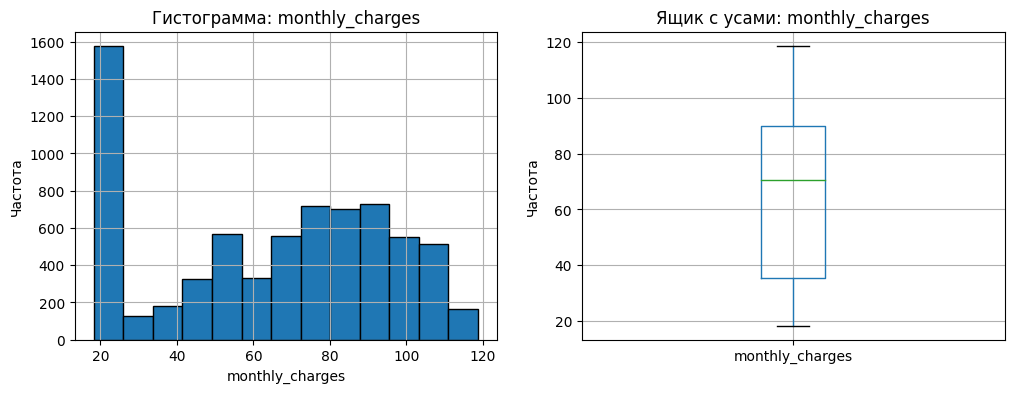

Анализ признака: total_charges


count    7043.000000
mean     2115.312885
std      2112.742814
min         0.000000
25%       436.750000
50%      1343.350000
75%      3236.690000
max      9221.380000
Name: total_charges, dtype: float64

Пропуски: 0


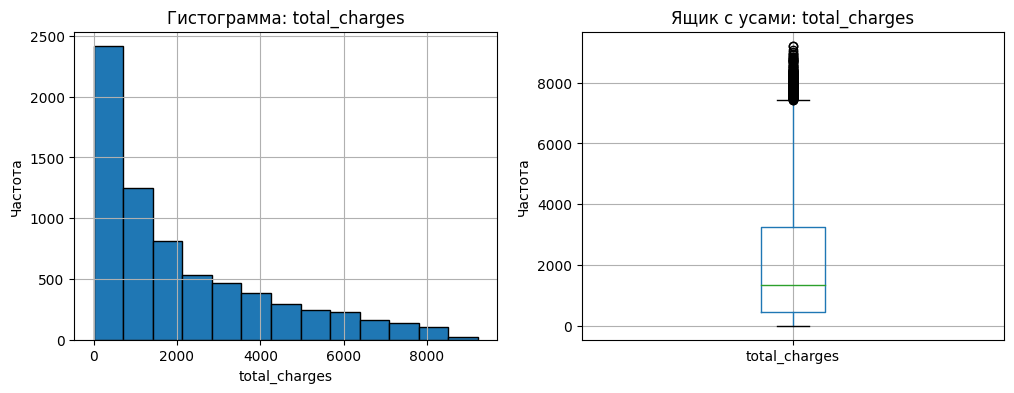

In [40]:
contract_new_df_num = ['monthly_charges', 'total_charges']

for col in contract_new_df_num:
    analyze_numeric(contract_new_df, col)

Анализ признака: type
Уникальных: 3
Пропуски: 0


Month-to-month    3875
Two year          1695
One year          1473
Name: type, dtype: int64

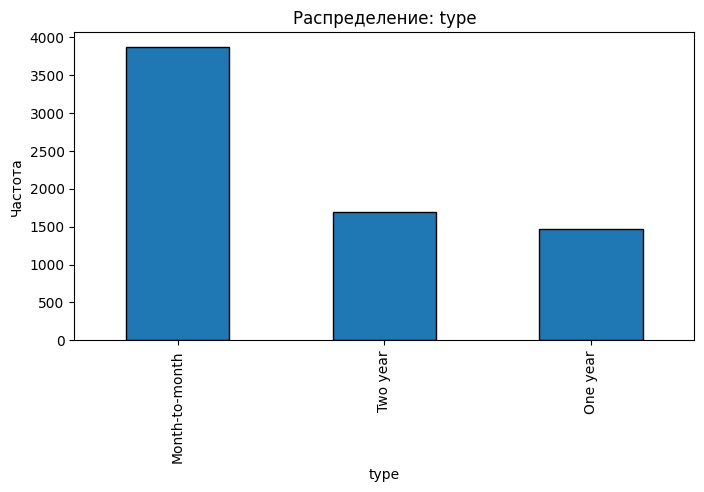

Анализ признака: paperless_billing
Уникальных: 2
Пропуски: 0


Yes    4171
No     2872
Name: paperless_billing, dtype: int64

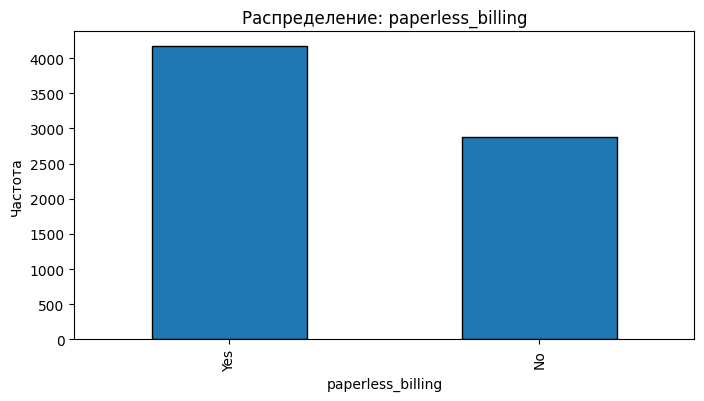

Анализ признака: payment_method
Уникальных: 4
Пропуски: 0


Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: payment_method, dtype: int64

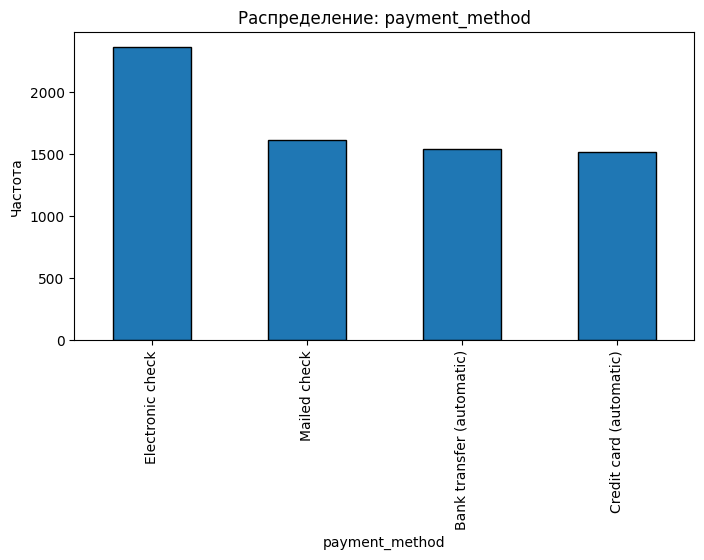

In [41]:
contract_new_df_cat = ['type', 'paperless_billing', 'payment_method']

for col in contract_new_df_cat:
    analyze_categorical(contract_new_df, col)

In [42]:
personal_new_df.dtypes

customer_id       object
gender            object
senior_citizen     int64
partner           object
dependents        object
dtype: object

Анализ признака: gender
Уникальных: 2
Пропуски: 0


Male      3555
Female    3488
Name: gender, dtype: int64

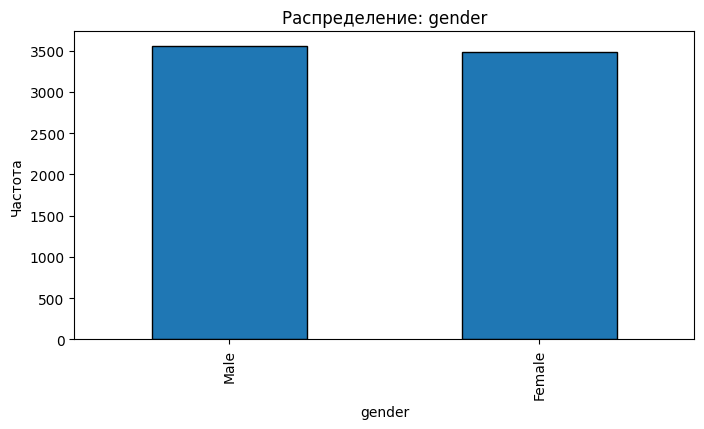

Анализ признака: senior_citizen
Уникальных: 2
Пропуски: 0


0    5901
1    1142
Name: senior_citizen, dtype: int64

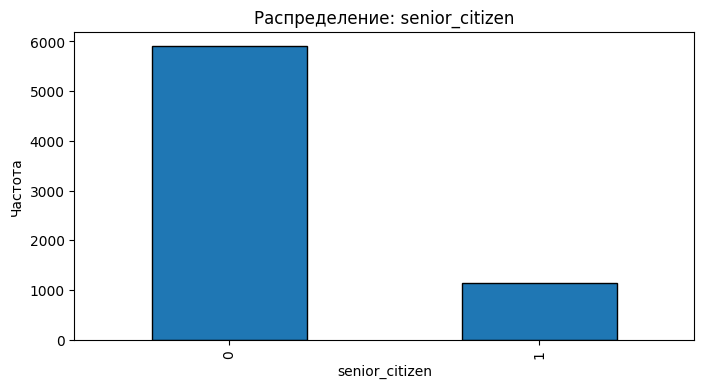

Анализ признака: partner
Уникальных: 2
Пропуски: 0


No     3641
Yes    3402
Name: partner, dtype: int64

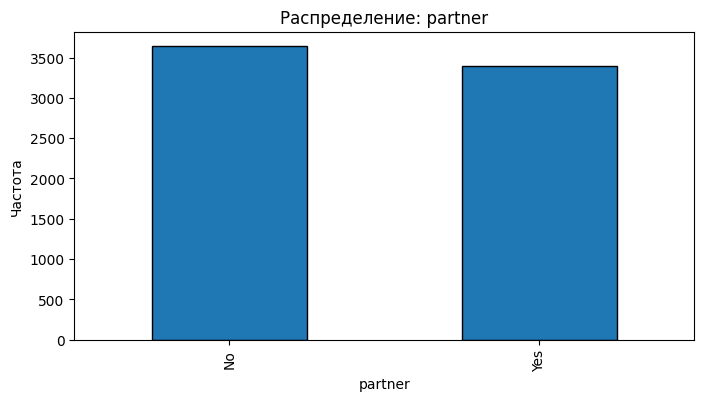

Анализ признака: dependents
Уникальных: 2
Пропуски: 0


No     4933
Yes    2110
Name: dependents, dtype: int64

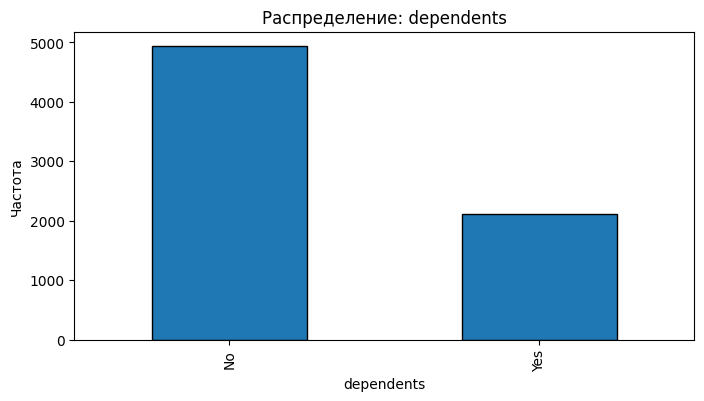

In [43]:
personal_new_df_col = ['gender', 'senior_citizen', 'partner', 'dependents']

for col in personal_new_df_col:
    analyze_categorical(personal_new_df, col)


In [44]:
internet_new_df.dtypes

customer_id          object
internet_service     object
online_security      object
online_backup        object
device_protection    object
tech_support         object
streaming_tv         object
streaming_movies     object
dtype: object

Анализ признака: internet_service
Уникальных: 2
Пропуски: 0


Fiber optic    3096
DSL            2421
Name: internet_service, dtype: int64

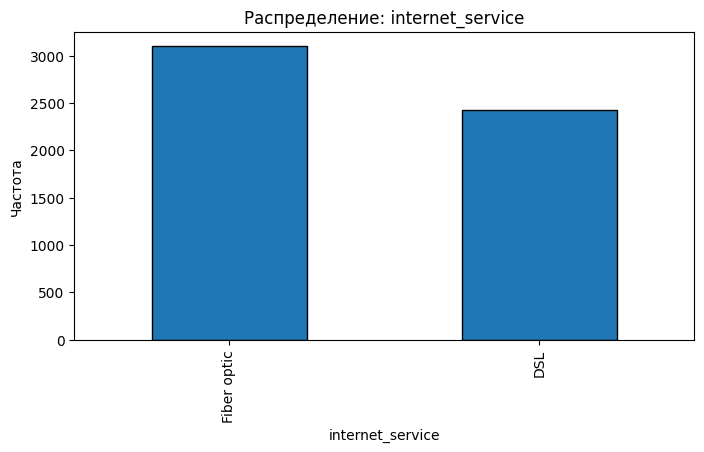

Анализ признака: online_security
Уникальных: 2
Пропуски: 0


No     3498
Yes    2019
Name: online_security, dtype: int64

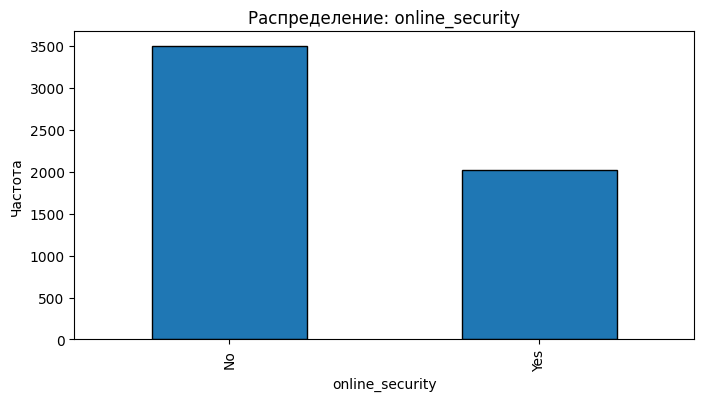

Анализ признака: online_backup
Уникальных: 2
Пропуски: 0


No     3088
Yes    2429
Name: online_backup, dtype: int64

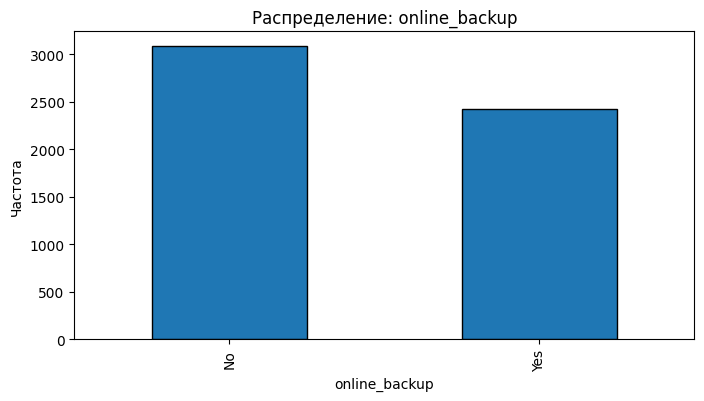

Анализ признака: device_protection
Уникальных: 2
Пропуски: 0


No     3095
Yes    2422
Name: device_protection, dtype: int64

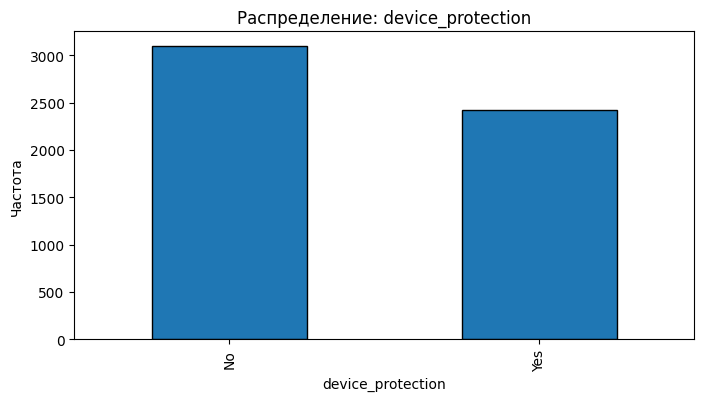

Анализ признака: tech_support
Уникальных: 2
Пропуски: 0


No     3473
Yes    2044
Name: tech_support, dtype: int64

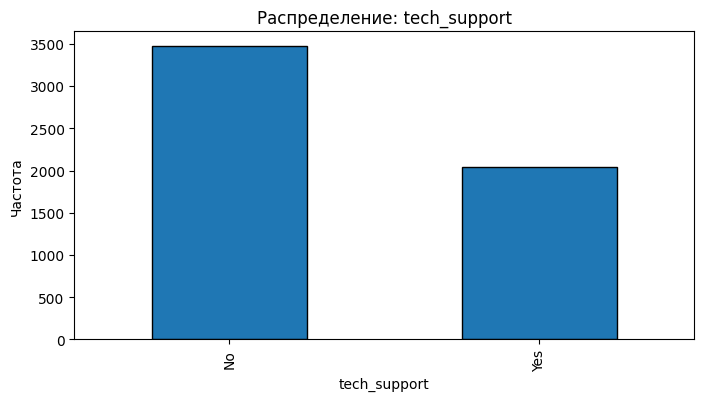

Анализ признака: streaming_tv
Уникальных: 2
Пропуски: 0


No     2810
Yes    2707
Name: streaming_tv, dtype: int64

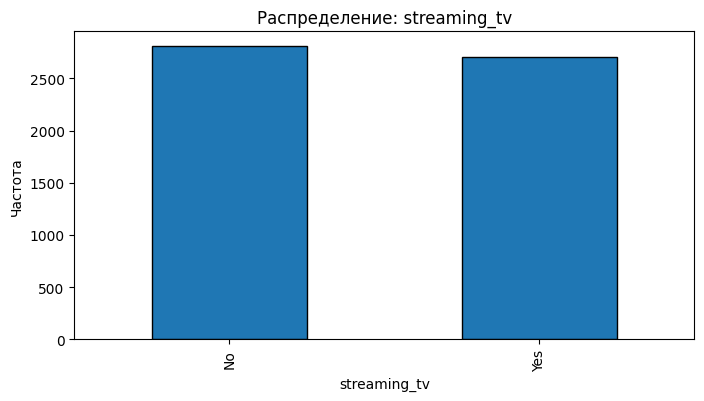

Анализ признака: streaming_movies
Уникальных: 2
Пропуски: 0


No     2785
Yes    2732
Name: streaming_movies, dtype: int64

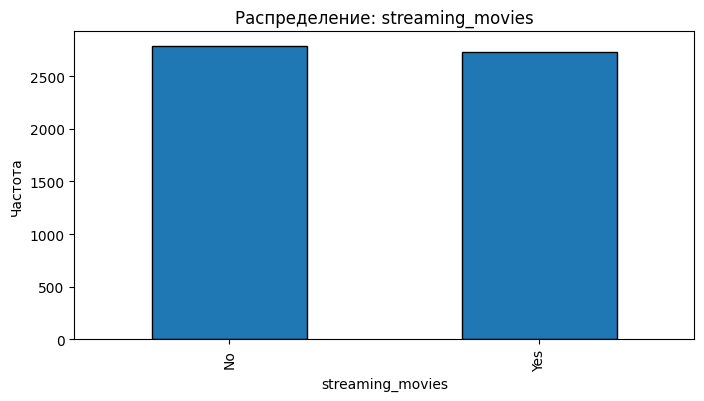

In [46]:
internet_new_df_col = ['internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support',
                      'streaming_tv', 'streaming_movies']

for col in internet_new_df_col:
    analyze_categorical(internet_new_df, col)
    

In [47]:
phone_new_df.dtypes

customer_id       object
multiple_lines    object
dtype: object

Анализ признака: multiple_lines
Уникальных: 2
Пропуски: 0


No     3390
Yes    2971
Name: multiple_lines, dtype: int64

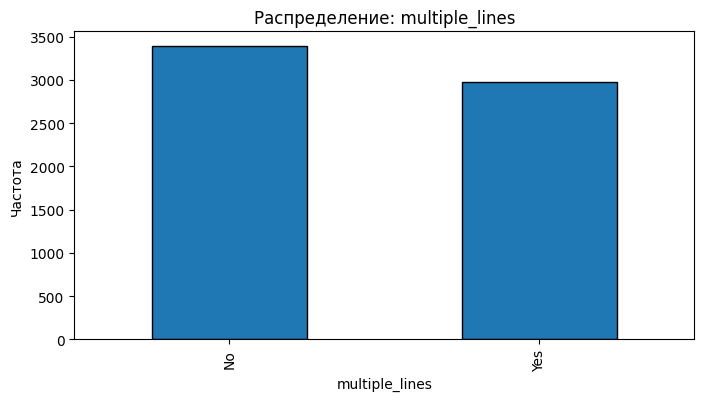

In [48]:
analyze_categorical(phone_new_df, 'multiple_lines')

### Conclusion from step 2

**Numerical characteristics**


**Histogram**

The distribution is heavily skewed to the right (the right tail is long).
Many customers have low total spend.
A significant portion are new customers, with total_charges close to 0.
There is a noticeable step: many values ​​are in the 0–1000 and 1000–2000 ranges.

**Boxplot**

Median ~1400.
Wide interquartile range.
Many outliers (black dots) – customers with total_charges > 6000–8000.
These values ​​are correct: these are customers with a long history of using the service.

Key takeaway for total_charges:

The feature has a pronounced right tail, a wide range, and many outliers, but all outliers are logical.
Missing values ​​(NaN) appear for new customers.

2. monthly_charges – histogram and boxplot output

**Histogram**

Several groups are visible (roughly representing the characteristics of different pricing plans).
Range from 18 to 118.
The distribution is nearly uniform, with no strong tail.
The customer density is high in the 70-100 range—this range corresponds to mid-range and high-end plans.

**Boxplot**

The median is around 70.
Some outliers (very high-end plans).
Moderate variability—the indicator is stable.

The main conclusion for monthly_charges:

This feature is normally distributed, with no extreme outliers.
It reflects current pricing and is more strongly related to the type of service than to the length of service the customer has been using.


**Categorical features**

- contract_new_df['type'] - mostly monthly payments.
- contract_new_df['paperless_billing'] - Most clients use electronic receipts (paperless billing). That is, they prefer digital methods of receiving invoices.
- contract_new_df['payment_method'] - electronic payment is the leading method. Mail payments and automatic card payments also have high values, but lower than electronic payments. Electronic checks are often a marker of high-churn customers, as this method is less "sticky." Automatic methods (credit card automatic / bank transfer automatic) are less popular → they are usually associated with low churn.
- personal_new_df_col['gender'] - the distribution is approximately equal among men and women.
- **personal_new_df['senior_citizen']** - the majority of clients are not retirees. Retirees make up a small portion.
- personal_new_df['partner'] - the distribution is almost uniform between the absence and presence of a partner, but there is still a slight bias towards the absence of a partner..
- personal_new_df['dependents'] - basically no dependents. The gap is more than half.
- internet_new_df['internet_service'] - The gap is noticeable, but not huge. This is important because Fiber customers tend to churn more often due to high costs.
- **internet_new_df['online security']** - ~3,500 not using vs. ~2,000 using this service. This indicator correlates with increased churn.
- internet_new_df['device_protection'] - mostly not used, but the gap is not big.
- **internet_new_df['tech_support']** - the gap is roughly the same as for online security: ~3,500 non-users versus ~2,000 users. Additional support reduces churn.
- internet_new_df['streaming_tv'] and internet_new_df['streaming_movies'] - the ratio is roughly the same, which is logical. After all, you have to pay for these services to use them. Both features can be used for customer segmentation, but are not very suitable for predicting customer churn.
- phone_new_df['multiple_lines'] - the same ratio between people who have one telephone connection and those who have several of these connections.


## Data consolidation

First, let's create a feature - contract duration in days

In [50]:
# If end_date is empty, replace it with the current date.
cutoff_date = pd.to_datetime('2020-02-01')

contract_new_df['effective_end_date'] = contract_new_df['end_date'].fillna(cutoff_date)

# tenure in days (as an integer)
contract_new_df['tenure'] = (
    contract_new_df['effective_end_date'] - contract_new_df['begin_date']
).dt.days

In [51]:
contract_new_df['tenure']

0         31
1       1036
2        123
3       1371
4        153
        ... 
7038     730
7039    2191
7040     337
7041     215
7042    2010
Name: tenure, Length: 7043, dtype: int64

**Merging Dataframes**

In [52]:
joined_df = contract_new_df.merge(personal_new_df, on = 'customer_id', how = 'left')

In [53]:
joined_df = joined_df.merge(internet_new_df, on = 'customer_id', how = 'left')

In [54]:
joined_df = joined_df.merge(phone_new_df, on = 'customer_id', how = 'left')

In [55]:
joined_df.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,effective_end_date,tenure,...,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,2020-02-01,31,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,2020-02-01,1036,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,2020-02-01,123,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60,2020-02-01,1371,...,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,2020-02-01,153,...,No,No,Fiber optic,No,No,No,No,No,No,No


In [56]:
display(len(joined_df))

7043

- Checking unique clients

In [57]:
joined_df['customer_id'].nunique()


7043

This means:
- no clients are duplicated

- the merge was performed correctly

## Exploratory analysis and preprocessing of the combined data frame

In [58]:
joined_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         7043 non-null   object        
 1   begin_date          7043 non-null   datetime64[ns]
 2   end_date            1101 non-null   datetime64[ns]
 3   type                7043 non-null   object        
 4   paperless_billing   7043 non-null   object        
 5   payment_method      7043 non-null   object        
 6   monthly_charges     7043 non-null   float64       
 7   total_charges       7043 non-null   float64       
 8   effective_end_date  7043 non-null   datetime64[ns]
 9   tenure              7043 non-null   int64         
 10  gender              7043 non-null   object        
 11  senior_citizen      7043 non-null   int64         
 12  partner             7043 non-null   object        
 13  dependents          7043 non-null   object      

In [59]:
joined_df.describe()

,monthly_charges,total_charges,tenure,senior_citizen
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,64.761692,2115.312885,898.555729,0.162147
std,30.090047,2112.742814,683.130510,0.368612
min,18.250000,0.000000,0.000000,0.000000
25%,35.500000,436.750000,276.000000,0.000000
50%,70.350000,1343.350000,761.000000,0.000000
75%,89.850000,3236.690000,1461.000000,0.000000
max,118.750000,9221.380000,2314.000000,1.000000


In [60]:
joined_df.dtypes

customer_id                   object
begin_date            datetime64[ns]
end_date              datetime64[ns]
type                          object
paperless_billing             object
payment_method                object
monthly_charges              float64
total_charges                float64
effective_end_date    datetime64[ns]
tenure                         int64
gender                        object
senior_citizen                 int64
partner                       object
dependents                    object
internet_service              object
online_security               object
online_backup                 object
device_protection             object
tech_support                  object
streaming_tv                  object
streaming_movies              object
multiple_lines                object
dtype: object

In [61]:
joined_df.isna().sum()

customer_id              0
begin_date               0
end_date              5942
type                     0
paperless_billing        0
payment_method           0
monthly_charges          0
total_charges            0
effective_end_date       0
tenure                   0
gender                   0
senior_citizen           0
partner                  0
dependents               0
internet_service      1526
online_security       1526
online_backup         1526
device_protection     1526
tech_support          1526
streaming_tv          1526
streaming_movies      1526
multiple_lines         682
dtype: int64

1) A group of features with 1,526 missing entries: internet_service, online_security, online_backup, device_protection, tech_support,
streaming_tv, streaming_movies.

Everywhere exactly 1526 NaN → means:

- These are the same clients.
- These clients don't have internet service.

That is:
if a client doesn't have internet service, they can't have online security, streaming, backup, etc.

These are not omissions in meaning - this is a lack of service (“No service”).

2) end_date — 5942 gaps

end_date is only available for customers who have left (churn = yes).

Active clients → end_date = NaN.

And we have already replaced them with effective_end_date.

That is, these 5942 NaN are not an error, they should be left as is.

3) multiple_lines - 682 passes

It means:

- 682 customers don't have phone service (phone_new_df).
- Therefore, the multiple_lines attribute is simply missing.

This is also a logical omission.

**Conclusion**

Let's replace NaN with NO. Because they don't simply use these services.

Because all these services depend on internet access.

- But this doesn't change the fact that the client can:

1) have a telephone connection

2) have monthly payments

3) have paperless billing

4) have partners/dependents, etc.

In [64]:
internet_cols = [
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies'
]

# 1) For clients without internet, set an explicit value in internet_service
joined_df['internet_service'] = joined_df['internet_service'].fillna('No internet')

#2) If there is no internet → all internet services = 'No internet'
joined_df.loc[joined_df['internet_service'] == 'No internet', internet_cols] = 'No internet'

#3) If there is internet (DSL/Fiber) → service gaps = 'No'
mask_has_internet = joined_df['internet_service'] != 'No internet'
joined_df.loc[mask_has_internet, internet_cols] = (
    joined_df.loc[mask_has_internet, internet_cols].fillna('No')
)

# 4) Telephony: NaN → no telephone service
joined_df['multiple_lines'] = joined_df['multiple_lines'].fillna('No phone service')

In [66]:
joined_df[internet_cols + ['internet_service', 'multiple_lines']].isna().sum()


online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
internet_service     0
multiple_lines       0
dtype: int64

In [67]:
joined_df.duplicated().sum()

0

In [68]:
joined_df.dtypes

customer_id                   object
begin_date            datetime64[ns]
end_date              datetime64[ns]
type                          object
paperless_billing             object
payment_method                object
monthly_charges              float64
total_charges                float64
effective_end_date    datetime64[ns]
tenure                         int64
gender                        object
senior_citizen                 int64
partner                       object
dependents                    object
internet_service              object
online_security               object
online_backup                 object
device_protection             object
tech_support                  object
streaming_tv                  object
streaming_movies              object
multiple_lines                object
dtype: object

Анализ признака: monthly_charges


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charges, dtype: float64

Пропуски: 0


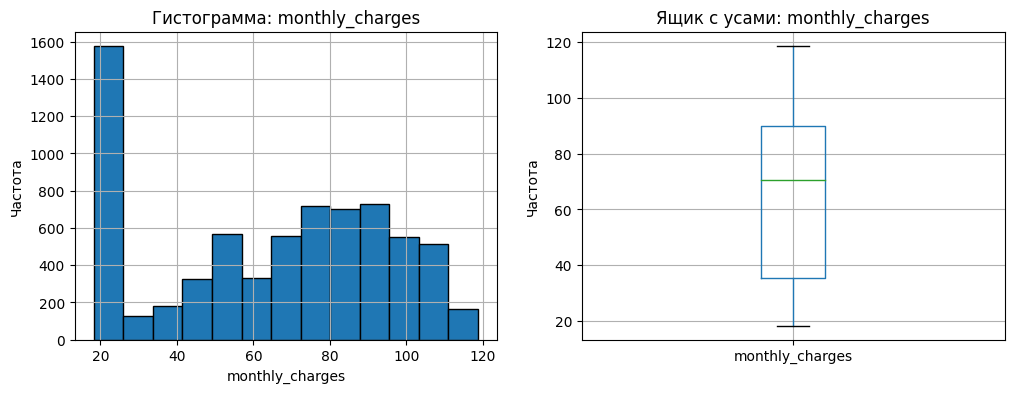

Анализ признака: total_charges


count    7043.000000
mean     2115.312885
std      2112.742814
min         0.000000
25%       436.750000
50%      1343.350000
75%      3236.690000
max      9221.380000
Name: total_charges, dtype: float64

Пропуски: 0


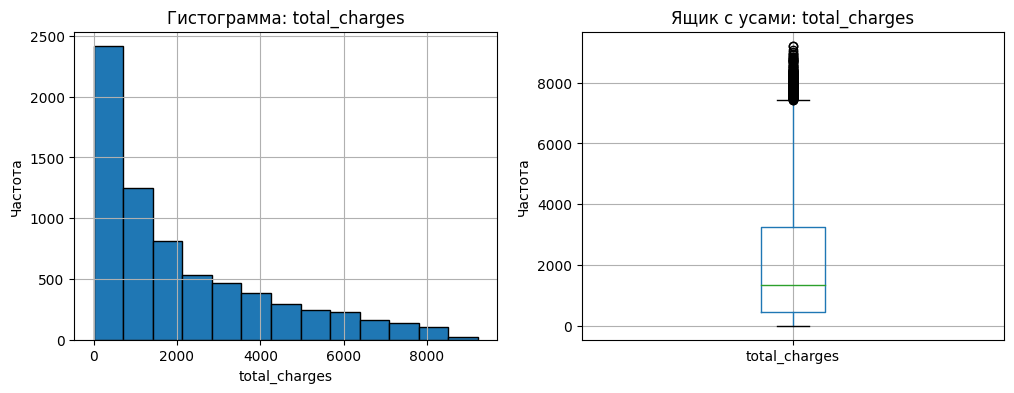

Анализ признака: tenure


count    7043.000000
mean      898.555729
std       683.130510
min         0.000000
25%       276.000000
50%       761.000000
75%      1461.000000
max      2314.000000
Name: tenure, dtype: float64

Пропуски: 0


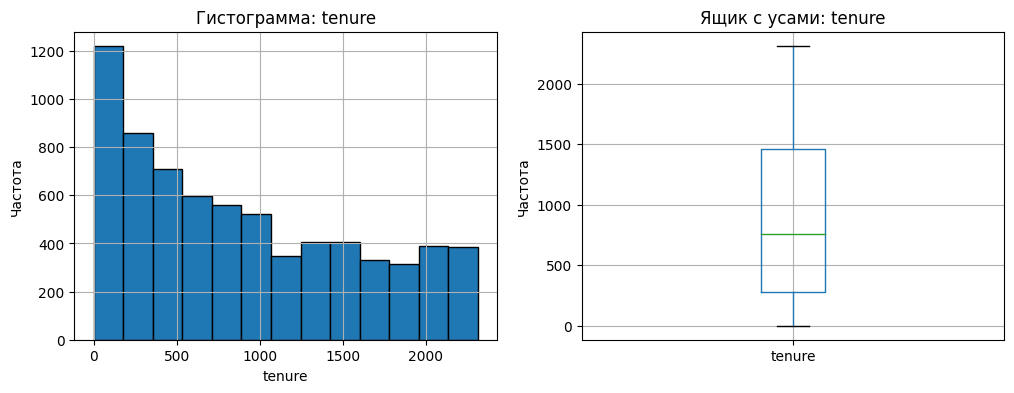

In [69]:
num = ['monthly_charges', 'total_charges', 'tenure']

for col in num:
    analyze_numeric(joined_df, col)

tenure (in days)
1) Histogram

- Many clients with low tenure → peak around 0–200 days.

- Then the distribution gradually decreases.

- There is a long tail up to ~2300 days (≈ 6.3 years).

2) Boxplot

- Median ~760 days (≈ 2 years).

- Large range: from 0 to >2000 days.

- A small number of outliers are completely normal - these are simply long-term clients.

Nothing has changed in monthly_charges.

But, for the record, let's write it again:

1. total_charges — histogram and boxplot output
**Histogram**

The distribution is heavily skewed to the right (the right tail is long).
Many customers have low total spend.
A significant portion are new customers, with total_charges close to 0.
There is a noticeable step: many values ​​are in the 0–1000 and 1000–2000 ranges.

**Boxplot**

Median ~1400.
Wide interquartile range.
Very many outliers (black dots)—customers with total_charges > 6000–8000.
These values ​​are correct: these are customers with a long history of using the service.

The main conclusion regarding total_charges:

The feature has a pronounced right tail, a large range, and many outliers, but all the outliers are logical.
Gaps (NaN) appear in new clients.

2. Monthly charges - histogram and boxplot output

**Гистограмма**

Several groups are visible (roughly representing the characteristics of different pricing plans).
The range is from 18 to 118.
The distribution is more or less uniform, with no strong tail.
The client density is high, ranging from 70 to 100, representing the mid-range and higher-end plans.

**Boxplot**

The median is around 70.
There are a few outliers (very expensive rates).
The variability is moderate—the indicator is stable.

The main conclusion regarding monthly_charges:

This indicator is normally distributed, without extreme outliers.
It reflects current rates and is more strongly related to the type of service than to the length of the customer's service.


Анализ признака: gender
Уникальных: 2
Пропуски: 0


Male      3555
Female    3488
Name: gender, dtype: int64

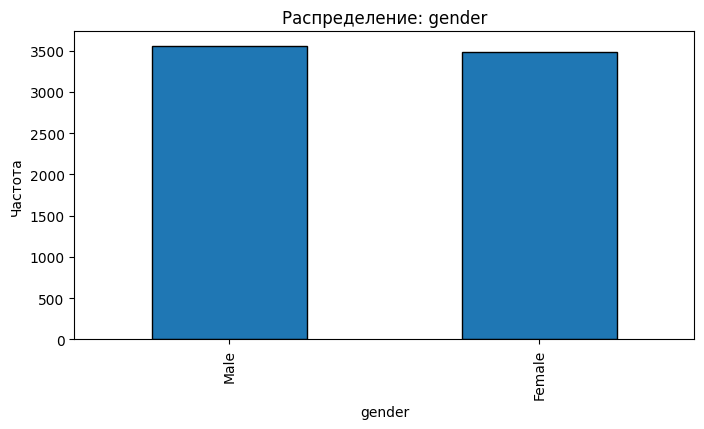

Анализ признака: senior_citizen
Уникальных: 2
Пропуски: 0


0    5901
1    1142
Name: senior_citizen, dtype: int64

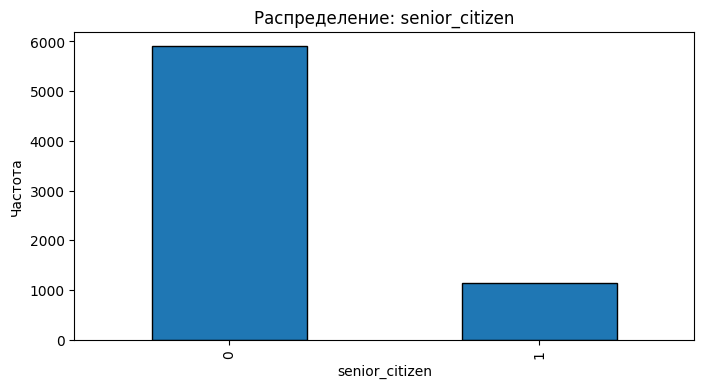

Анализ признака: partner
Уникальных: 2
Пропуски: 0


No     3641
Yes    3402
Name: partner, dtype: int64

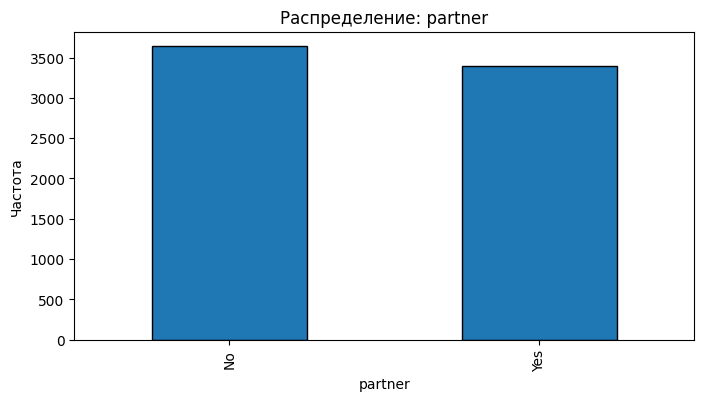

Анализ признака: dependents
Уникальных: 2
Пропуски: 0


No     4933
Yes    2110
Name: dependents, dtype: int64

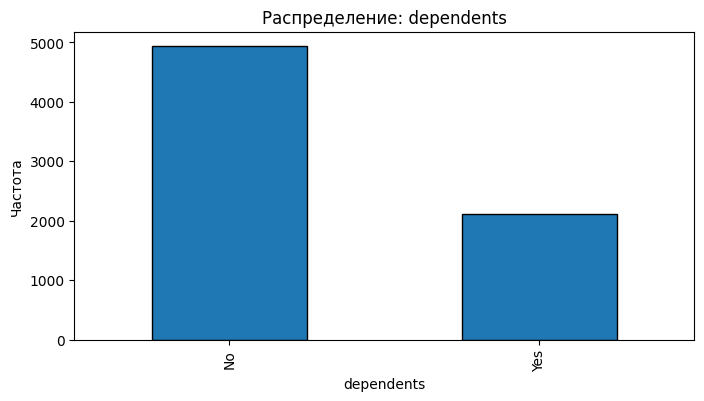

Анализ признака: internet_service
Уникальных: 3
Пропуски: 0


Fiber optic    3096
DSL            2421
No internet    1526
Name: internet_service, dtype: int64

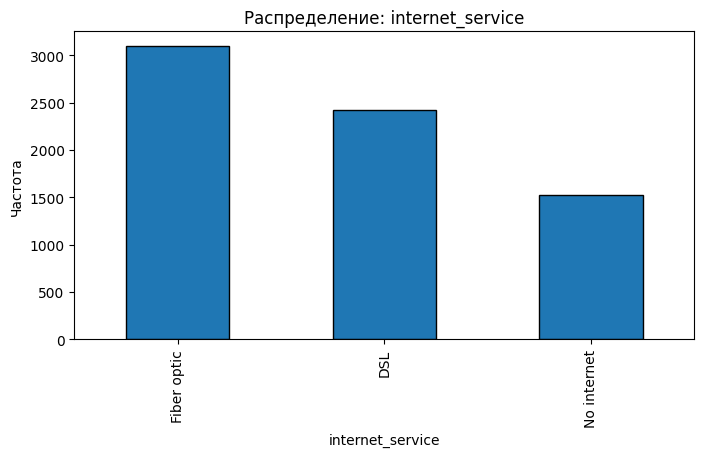

Анализ признака: online_security
Уникальных: 3
Пропуски: 0


No             3498
Yes            2019
No internet    1526
Name: online_security, dtype: int64

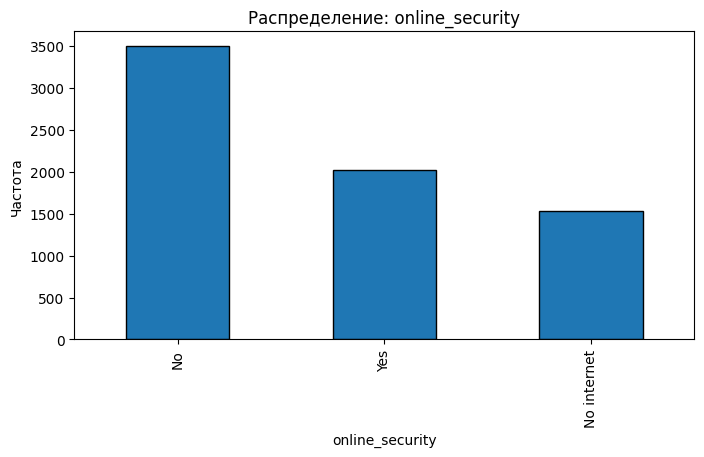

Анализ признака: online_backup
Уникальных: 3
Пропуски: 0


No             3088
Yes            2429
No internet    1526
Name: online_backup, dtype: int64

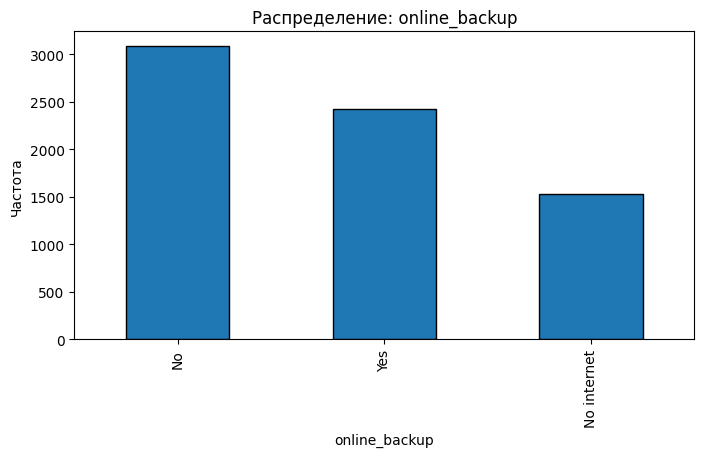

Анализ признака: device_protection
Уникальных: 3
Пропуски: 0


No             3095
Yes            2422
No internet    1526
Name: device_protection, dtype: int64

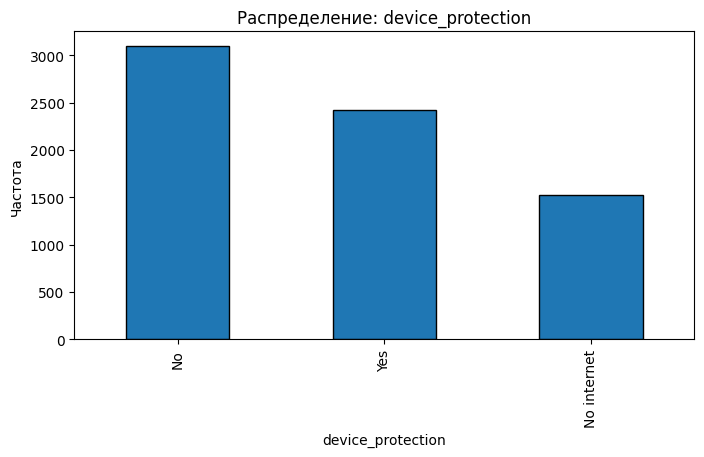

Анализ признака: tech_support
Уникальных: 3
Пропуски: 0


No             3473
Yes            2044
No internet    1526
Name: tech_support, dtype: int64

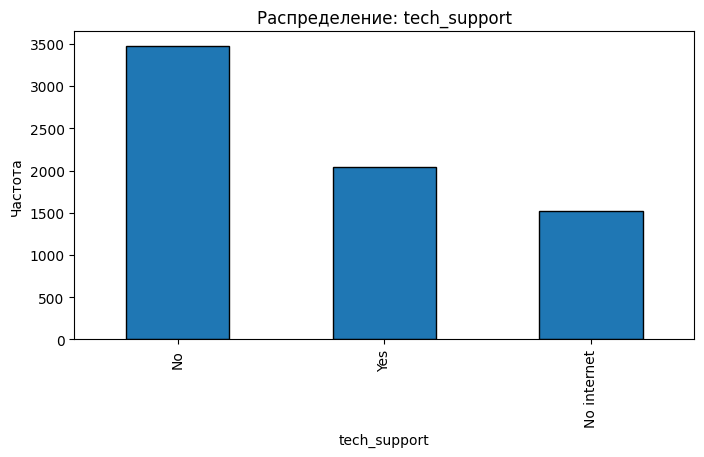

Анализ признака: streaming_tv
Уникальных: 3
Пропуски: 0


No             2810
Yes            2707
No internet    1526
Name: streaming_tv, dtype: int64

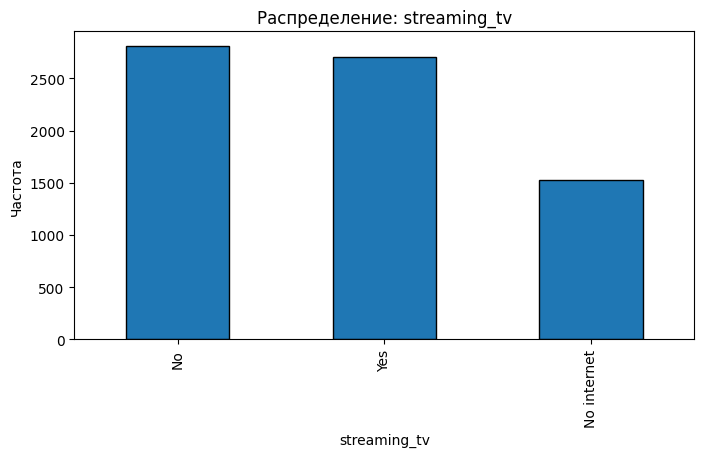

Анализ признака: streaming_movies
Уникальных: 3
Пропуски: 0


No             2785
Yes            2732
No internet    1526
Name: streaming_movies, dtype: int64

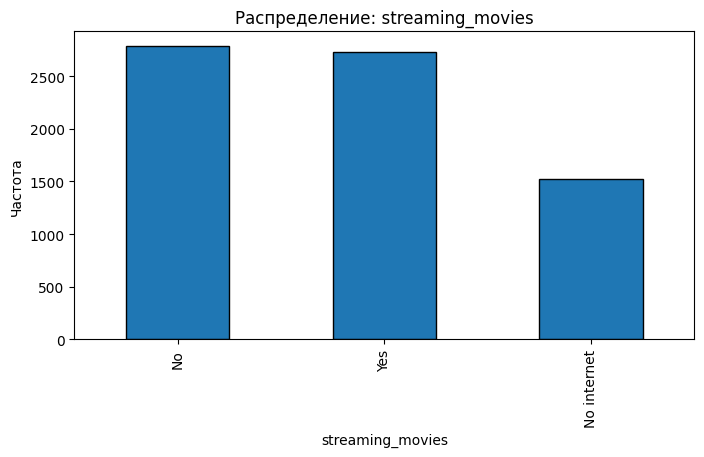

Анализ признака: multiple_lines
Уникальных: 3
Пропуски: 0


No                  3390
Yes                 2971
No phone service     682
Name: multiple_lines, dtype: int64

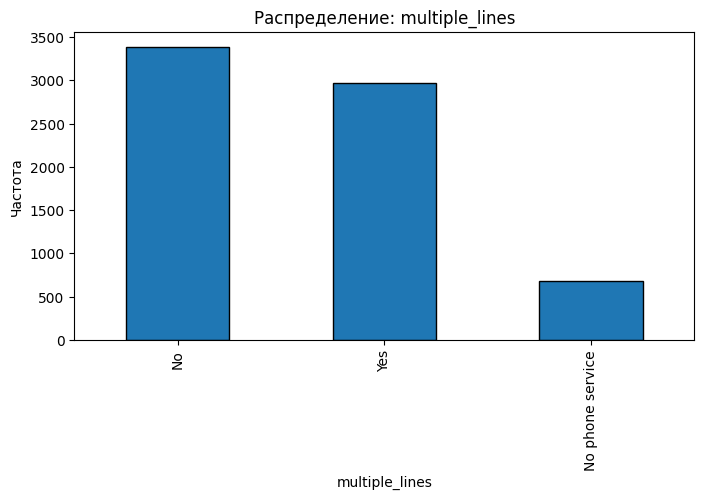

In [70]:
cat = ['gender', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 
       'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']

for col in cat:
    analyze_categorical(joined_df, col)

**Categorical features**

- ['type'] - mostly monthly payments.
- ['paperless_billing'] - Most customers use electronic receipts (paperless billing). That is, they prefer digital methods of receiving invoices.
- ['payment_method'] - electronic payment is the leading method. Mail payments and automatic card payments also have high values, but lower than electronic ones. Electronic checks are often a marker of high-churn customers, as this method is less "sticky." Automatic methods (credit card automatic / bank transfer automatic) are less popular → they are usually associated with low churn.
- ['gender'] - the distribution is approximately equal among men and women.
- **['senior_citizen']** - the majority of clients are not retirees. Retirees make up a small portion.
- ['partner'] - the distribution is almost uniform between the absence and presence of a partner, but there is still a slight shift towards the absence of a partner.
- ['dependents'] - basically there are no dependents. The gap is more than half.
- ['internet_service'] - The gap is noticeable, but not huge. This is important because Fiber customers tend to churn more often due to high costs. A new value, 'NO', has been added, indicating no internet service. 
- **['online security']** - The difference is almost twofold in the direction of the lack of services. This indicator correlates with increased churn. A new value, 'NO', has been added, indicating the absence of internet services.
- ['device_protection'] - generally not used, the gap is also twofold. A new value, 'NO', has been added, indicating no internet service.
- **['tech_support']** - the gap is more than twice the number of users who are not receiving the service. Additional support reduces churn.
- ['streaming_tv'] and ['streaming_movies'] - a slight increase in the absence of the service. After all, you have to pay for these services first to use them. Both features can be used for customer segmentation, but are not very suitable for predicting customer churn.
- ['multiple_lines'] - a slight increase in the absence of services for those with one telephone connection, compared to those with several of these connections.


**Conclusion**

EDA showed basically the same results, except for the new columns and the columns we modified.

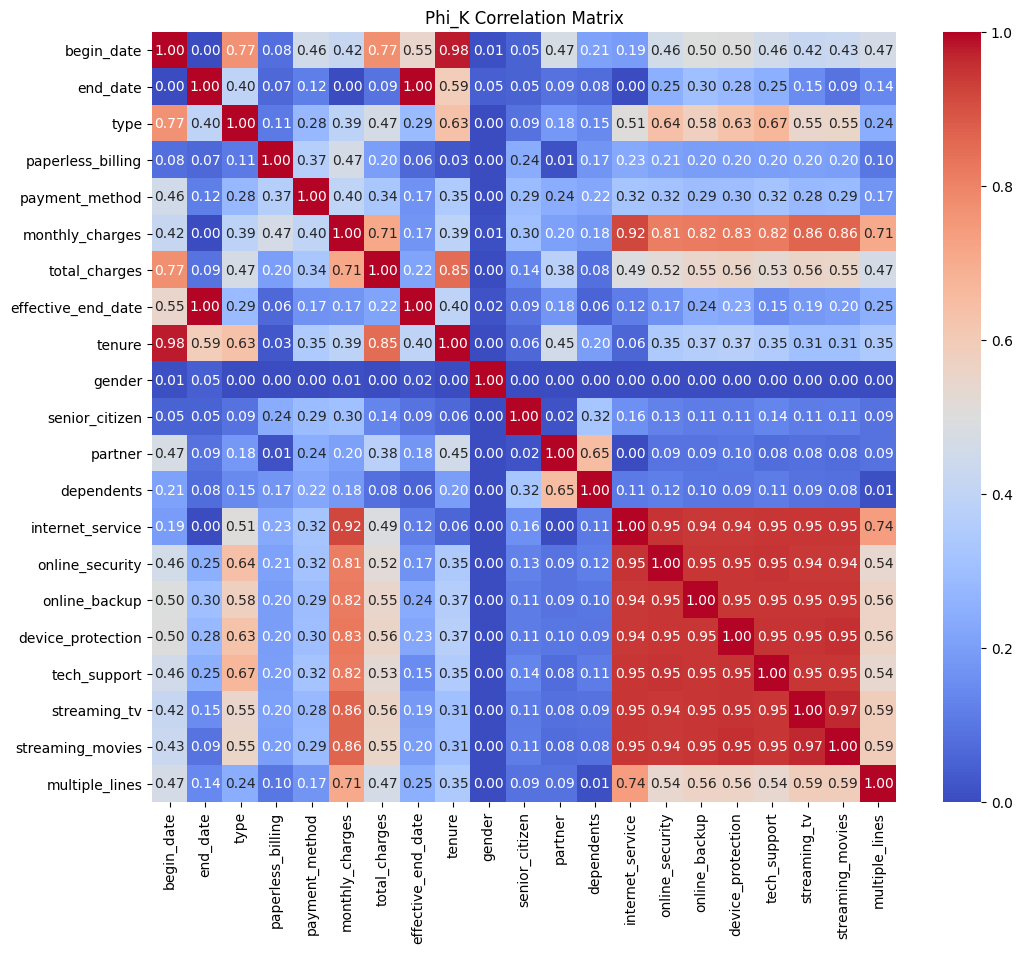

In [71]:
# numeric columns
num = ['monthly_charges', 'total_charges', 'tenure']

# Phi_K correlation matrix
corr_matrix = joined_df.phik_matrix(interval_cols=num)


corr_matrix = corr_matrix.drop(index = 'customer_id', columns=['customer_id'])
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Phi_K Correlation Matrix')
plt.show()

Very strong correlations (almost duplicates)

Looking at values around ±1.0:

begin_date ↔ tenure ≈ -0.98
The later the client joined, the shorter their tenure.
- It's almost the same thing.
Conclusion: keep tenure for the model, but you can safely discard begin_date.

end_date ↔ effective_end_date ≈ 0.99–1.00
For departed customers, the dates are the same, for current customers, end_date = NaN, and effective_end_date = the cutoff date.
- Only one feature is sufficient in the model.
We'll use tenure

total_charges ↔ tenure ≈ 0.85
And total_charges ≈ monthly_charges * tenure.
- This is an almost deterministic relationship.
The logic for the model:

We'll keep tenure and monthly_charges,

and we can remove total_charges to avoid introducing unnecessary multicollinearity (especially for linear models).

2. Strong relationships between services

The "packets" are clearly visible:

internet_service ↔ streaming_tv / streaming_movies / online_security / tech_support — high values.
Logically, all these services are only available with internet access.

streaming_tv ↔ streaming_movies ≈ 0.7+
They often come in pairs (the client that connects TV also connects movies).
- You can leave both for the model, but keep in mind that they partially overlap. This isn't a problem in tree/boosted streams, but it can interfere with linear streams.

**That is to say**:

- internet_service ↔ all internet services (0.90–0.95)

If there's no internet, all services are "No internet":
=> perfect conditionality, logical dependence.

- streaming_tv ↔ streaming_movies (~0.7)

Often purchased together – remains consistent.

- online_security / online_backup / device_protection / tech_support (~0.4–0.6)

Visible security packets are normal.

3. Weak/Expected Links

1) senior_citizen:

Phi_K ≈ 0.05–0.15 with all features—that is, a nearly independent flag.

This is the correct behavior: age category
by itself is not directly related to either internet services or contract type.

- It can be safely used in the model—it doesn't create noise.

2) gender

Practically uncorrelated with any feature:

Phi_K is near zero.

- It may be weak for the model, but it can be retained.

3) partner / dependents

Moderate correlations:

partner ↔ dependents ≈ 0.30–0.35

The rest are at the level of weak correlations.

- Both features carry behavioral information and are useful.

4) paperless_billing / payment_method

Correlations of 0.2–0.3:

Small effect on choice of plans or services;

- correlations do not create problems.

**Let's select the features we need**

In [72]:
features = [
    'monthly_charges',
    'tenure',
    'senior_citizen',
    'type',
    'paperless_billing',
    'payment_method',
    'gender',
    'partner',
    'dependents',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'multiple_lines'
]

**Creating a target feature**

In [73]:
joined_df['churn'] = joined_df['end_date'].notna().astype(int)

In [74]:
joined_df['churn'].value_counts()

0    5942
1    1101
Name: churn, dtype: int64

In [75]:
target = 'churn'

##  Data preparation

In [76]:
ohe_columns = ['type',
    'paperless_billing',
    'payment_method',
    'gender',
    'partner',
    'dependents',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'multiple_lines',
    'senior_citizen'
 ]


num_columns = [ 'monthly_charges',
    'tenure'
]

In [77]:
X = joined_df[features]
y = joined_df[target]

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = TEST_SIZE, stratify = y
)

In [79]:
ohe_pipe = Pipeline([
    ('simpleImputer_ohe', SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')),
    ('ohe', OneHotEncoder(drop = 'first', handle_unknown = 'ignore', sparse_output = False))

])

In [80]:
num_pipe = Pipeline([
    ('simpleImputer_num', SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')),
    ('scaler', MinMaxScaler())  
])

In [81]:
data_preprocessor = ColumnTransformer(
    [
    ('ohe', ohe_pipe, ohe_columns),
    ('num', num_pipe, num_columns)  
    ],
    remainder = 'passthrough'
    
)

## Training machine learning models

In [82]:
final_pipe = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state = RANDOM_STATE))
    
])

#### DecisionTreeClassifier

In [83]:
def objective(trial):
    # Hyperparameter selection
    max_depth = trial.suggest_int('max_depth', 3, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)

    # Model in Pipeline
    model = Pipeline([
        ('preprocessor', data_preprocessor),  
        ('model', DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE
        ))
    ])

    # Cross-validation (5 folds, stratified)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs = -1)

    return np.mean(scores)

In [84]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    final_pipe,  # Pipeline with preprocessor and model
    X, y,
    cv=cv,
    scoring='roc_auc',
    error_score='raise'  
)

display(scores, scores.mean())

array([0.61419451, 0.64895634, 0.6335432 , 0.62382155, 0.64183502])

0.6324701235775791

In [85]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=100)

[I 2025-11-24 13:41:24,943] A new study created in memory with name: no-name-75709fc4-85e8-458b-b859-749eee8bb8e4
[I 2025-11-24 13:41:33,164] Trial 0 finished with value: 0.7414952140037261 and parameters: {'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.7414952140037261.
[I 2025-11-24 13:41:36,856] Trial 1 finished with value: 0.7798093264566086 and parameters: {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.7798093264566086.
[I 2025-11-24 13:41:40,381] Trial 2 finished with value: 0.7679666775536216 and parameters: {'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.7798093264566086.
[I 2025-11-24 13:41:40,741] Trial 3 finished with value: 0.7508625071854427 and parameters: {'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.7798093264566086.
[I 2025-11-24 13:41:41,090] Trial 4 finished with value: 0.7664963

In [87]:
# Better hyperparameters
best_params = study.best_params
display("Best parameters:", best_params)
best_val_dt = study.best_value
display(f'{best_val_dt:.4}')

'Best parameters:'

{'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 1}

'0.7826'

#### LogisticRegression

In [88]:
def objective(trial):
    # Hyperparameter selection
    C=trial.suggest_float("lr_C", 0.01, 10.0, log=True)
    penalty='l2'
    solver='liblinear'
    max_iter=1000
    # Модель в Pipeline
    model = Pipeline([
        ('preprocessor', data_preprocessor),  # previously defined ColumnTransformer
        ('model', LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            max_iter = max_iter,
            random_state = RANDOM_STATE
        ))
    ])

    # Cross-validation (5 folds, stratified)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs = -1)

    return np.mean(scores)

In [89]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=100)

[I 2025-11-24 13:42:40,355] A new study created in memory with name: no-name-2df18738-082a-4239-b434-873ad089d3d2
[I 2025-11-24 13:42:40,715] Trial 0 finished with value: 0.7532221818580407 and parameters: {'lr_C': 2.362232906418191}. Best is trial 0 with value: 0.7532221818580407.
[I 2025-11-24 13:42:41,073] Trial 1 finished with value: 0.7532399679514242 and parameters: {'lr_C': 3.056533996132034}. Best is trial 1 with value: 0.7532399679514242.
[I 2025-11-24 13:42:41,441] Trial 2 finished with value: 0.7532448812022713 and parameters: {'lr_C': 0.6112387907645468}. Best is trial 2 with value: 0.7532448812022713.
[I 2025-11-24 13:42:41,799] Trial 3 finished with value: 0.7512666191597871 and parameters: {'lr_C': 0.1218273142356802}. Best is trial 2 with value: 0.7532448812022713.
[I 2025-11-24 13:42:42,150] Trial 4 finished with value: 0.7144024338886681 and parameters: {'lr_C': 0.016184190665967903}. Best is trial 2 with value: 0.7532448812022713.
[I 2025-11-24 13:42:42,529] Trial 5 

In [90]:
# Better hyperparameters
best_params = study.best_params
display("Best parameters:", best_params)
best_val_lg = study.best_value
display(f'{best_val_lg:.4}')

'Best parameters:'

{'lr_C': 1.0927386604036788}

'0.7533'

#### Random_Forest

In [91]:
def objective(trial):
    # Hyperparameter selection
    n_estimators=trial.suggest_int("rf_n_estimators", 100, 300, step=50)
    max_depth=trial.suggest_int("rf_max_depth", 3, 10)
    min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 10)
    min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 5)
    max_features=trial.suggest_categorical("rf_max_features", ["sqrt", "log2"])
    # Model in Pipeline
    model = Pipeline([
        ('preprocessor', data_preprocessor),  
        ('model', RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
        n_jobs=-1
        ))
    ])

    # Cross-validation (5 folds, stratified)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs = -1)

    return np.mean(scores)

In [92]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=100)

[I 2025-11-24 13:43:29,473] A new study created in memory with name: no-name-589520eb-6d7d-4ca2-ad03-4b90b6512abb
[I 2025-11-24 13:43:32,988] Trial 0 finished with value: 0.8062980463418252 and parameters: {'rf_n_estimators': 250, 'rf_max_depth': 9, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 2, 'rf_max_features': 'log2'}. Best is trial 0 with value: 0.8062980463418252.
[I 2025-11-24 13:43:35,962] Trial 1 finished with value: 0.807400207783936 and parameters: {'rf_n_estimators': 200, 'rf_max_depth': 9, 'rf_min_samples_split': 6, 'rf_min_samples_leaf': 4, 'rf_max_features': 'log2'}. Best is trial 1 with value: 0.807400207783936.
[I 2025-11-24 13:43:38,423] Trial 2 finished with value: 0.7563163600801557 and parameters: {'rf_n_estimators': 200, 'rf_max_depth': 3, 'rf_min_samples_split': 9, 'rf_min_samples_leaf': 5, 'rf_max_features': 'log2'}. Best is trial 1 with value: 0.807400207783936.
[I 2025-11-24 13:43:39,869] Trial 3 finished with value: 0.7663490403121382 and parameters: {'

In [93]:
# Better hyperparameters
best_params = study.best_params
display("Best parameters:", best_params)
best_value_rf = study.best_value
display(f'{best_value_rf:.4}')

'Best parameters:'

{'rf_n_estimators': 250,
 'rf_max_depth': 9,
 'rf_min_samples_split': 9,
 'rf_min_samples_leaf': 1,
 'rf_max_features': 'sqrt'}

'0.8162'

#### Gradient Boosting

In [94]:
def objective_gb(trial):
    # 1. Selecting hyperparameters for Gradient Boosting
    n_estimators = trial.suggest_int("gb_n_estimators", 100, 400, step=50)
    learning_rate = trial.suggest_float("gb_learning_rate", 0.01, 0.3, log=True)
    max_depth = trial.suggest_int("gb_max_depth", 2, 5)
    min_samples_split = trial.suggest_int("gb_min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("gb_min_samples_leaf", 1, 10)
    subsample = trial.suggest_float("gb_subsample", 0.6, 1.0)

    gb_clf = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        random_state=RANDOM_STATE
    )

    model = Pipeline([
        ('preprocessor', data_preprocessor),
        ('model', gb_clf)
    ])

    # 2. Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        model,
        X_train, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs = -1
    )

    return np.mean(scores)


In [95]:
study_gb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_gb.optimize(objective_gb, n_trials=50)

[I 2025-11-24 13:48:46,193] A new study created in memory with name: no-name-1cea15a3-67df-400a-a63b-45e7d2261aa9
[I 2025-11-24 13:48:56,343] Trial 0 finished with value: 0.9119732360982674 and parameters: {'gb_n_estimators': 350, 'gb_learning_rate': 0.16736384308688904, 'gb_max_depth': 4, 'gb_min_samples_split': 8, 'gb_min_samples_leaf': 1, 'gb_subsample': 0.9247463387805392}. Best is trial 0 with value: 0.9119732360982674.
[I 2025-11-24 13:49:03,815] Trial 1 finished with value: 0.9024867421340336 and parameters: {'gb_n_estimators': 250, 'gb_learning_rate': 0.13425304242933106, 'gb_max_depth': 4, 'gb_min_samples_split': 15, 'gb_min_samples_leaf': 5, 'gb_subsample': 0.9448969558063345}. Best is trial 0 with value: 0.9119732360982674.
[I 2025-11-24 13:49:12,771] Trial 2 finished with value: 0.8476619002828611 and parameters: {'gb_n_estimators': 250, 'gb_learning_rate': 0.013457769863885992, 'gb_max_depth': 5, 'gb_min_samples_split': 18, 'gb_min_samples_leaf': 3, 'gb_subsample': 0.85673

In [101]:
# Better hyperparameters
best_params_gb = study_gb.best_params
display("Best parameters:", best_params_gb)
best_value_gb = study_gb.best_value
display(f'{best_value_gb:.4}')

'Best parameters:'

{'gb_n_estimators': 400,
 'gb_learning_rate': 0.16172565575272457,
 'gb_max_depth': 3,
 'gb_min_samples_split': 10,
 'gb_min_samples_leaf': 1,
 'gb_subsample': 0.988257874394731}

'0.9189'

#### XGBoost

In [98]:
def objective_xgb(trial):
    # 1. XGBoost hyperparameter selection
    n_estimators = trial.suggest_int("xgb_n_estimators", 100, 400, step=50)
    max_depth = trial.suggest_int("xgb_max_depth", 2, 8)
    learning_rate = trial.suggest_float("xgb_learning_rate", 0.01, 0.3, log=True)
    subsample = trial.suggest_float("xgb_subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("xgb_colsample_bytree", 0.6, 1.0)
    min_child_weight = trial.suggest_int("xgb_min_child_weight", 1, 10)
    gamma = trial.suggest_float("xgb_gamma", 0.0, 5.0)

    # 2. XGBoost model in Pipeline
    model = Pipeline([
        ('preprocessor', data_preprocessor),
        ('model', XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=min_child_weight,
            gamma=gamma,
            random_state=RANDOM_STATE,
            objective='binary:logistic',
            eval_metric='logloss',
            n_jobs = -1  
        ))
    ])

    # 3. Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        model,
        X_train, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs= -1  # first without parallelism
    )

    return np.mean(scores)

In [99]:
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_xgb.optimize(objective_xgb, n_trials=50)

[I 2025-11-24 13:55:42,849] A new study created in memory with name: no-name-bf695706-cb27-42e7-8d83-63aa2945ed42
[I 2025-11-24 13:55:44,148] Trial 0 finished with value: 0.8379377557548511 and parameters: {'xgb_n_estimators': 350, 'xgb_max_depth': 7, 'xgb_learning_rate': 0.07576757120891892, 'xgb_subsample': 0.7447659560005327, 'xgb_colsample_bytree': 0.6278787981622203, 'xgb_min_child_weight': 9, 'xgb_gamma': 2.346321960444555}. Best is trial 0 with value: 0.8379377557548511.
[I 2025-11-24 13:55:45,601] Trial 1 finished with value: 0.8621103388004612 and parameters: {'xgb_n_estimators': 350, 'xgb_max_depth': 5, 'xgb_learning_rate': 0.11067916223749162, 'xgb_subsample': 0.7725829951609676, 'xgb_colsample_bytree': 0.9448969558063345, 'xgb_min_child_weight': 6, 'xgb_gamma': 0.43656909314711057}. Best is trial 1 with value: 0.8621103388004612.
[I 2025-11-24 13:55:46,832] Trial 2 finished with value: 0.8384798969314856 and parameters: {'xgb_n_estimators': 350, 'xgb_max_depth': 8, 'xgb_lea

In [100]:
# Better hyperparameters
best_params = study_xgb.best_params
display("Best parameters:", best_params)
best_value_xgb = study_xgb.best_value
display(f'{best_value_xgb:.4}')

'Best parameters:'

{'xgb_n_estimators': 250,
 'xgb_max_depth': 6,
 'xgb_learning_rate': 0.20715709313427752,
 'xgb_subsample': 0.8894003376640909,
 'xgb_colsample_bytree': 0.693004404759039,
 'xgb_min_child_weight': 1,
 'xgb_gamma': 0.6800579387277598}

'0.8974'

**Our best cross-validation model is GradientBoosting**

In [106]:
# 1. The Best Gradient Boosting Model
best_params_gb = study_gb.best_trial.params


gb_best = GradientBoostingClassifier(
    n_estimators = best_params_gb['gb_n_estimators'],
    learning_rate = best_params_gb['gb_learning_rate'],
    max_depth = best_params_gb['gb_max_depth'],
    min_samples_split = best_params_gb['gb_min_samples_split'],
    min_samples_leaf = best_params_gb['gb_min_samples_leaf'],
    subsample = best_params_gb['gb_subsample'],
    random_state = RANDOM_STATE
)



gb_pipe_best = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', gb_best)
])

gb_pipe_best.fit(X_train, y_train)



y_test_pred_gb  = gb_pipe_best.predict_proba(X_test)[:, 1]


display("GB ROC-AUC test: ", roc_auc_score(y_test,  y_test_pred_gb))



'GB ROC-AUC test: '

0.9289612137526

In [107]:
# Dummy model
dummy = Pipeline([
    ('preprocessor', data_preprocessor),  # the same preprocessor
    ('model', DummyClassifier(strategy='most_frequent'))  # or 'stratified', 'uniform'
])

# Training
dummy.fit(X_train, y_train)

# Prediction
y_pred_dummy = dummy.predict_proba(X_test)[:, 1]

# Metrics
roc_dummy = roc_auc_score(y_test, y_pred_dummy)

display(f"ROC-AUC DummyClassifier: {roc_dummy:.4f}")

'ROC-AUC DummyClassifier: 0.5000'

Here we simply confirmed that our model predicts better than the random model.

#### Shap

In [108]:
# 1 — we get the preprocessor and the model
preprocessor = gb_pipe_best.named_steps['preprocessor']
gb_model = gb_pipe_best.named_steps['model']

# 2 — transform X_train in the same way as in pipeline
X_train_processed = preprocessor.transform(X_train)

# 3 — Initializing TreeExplainer (ideal for GB, XGB, RF)
explainer = shap.TreeExplainer(gb_model)

# 4 — shap-values calculation
shap_values = explainer.shap_values(X_train_processed)



In [109]:
# get a list of features after transformation
feature_names = gb_pipe_best.named_steps['preprocessor'].get_feature_names_out()

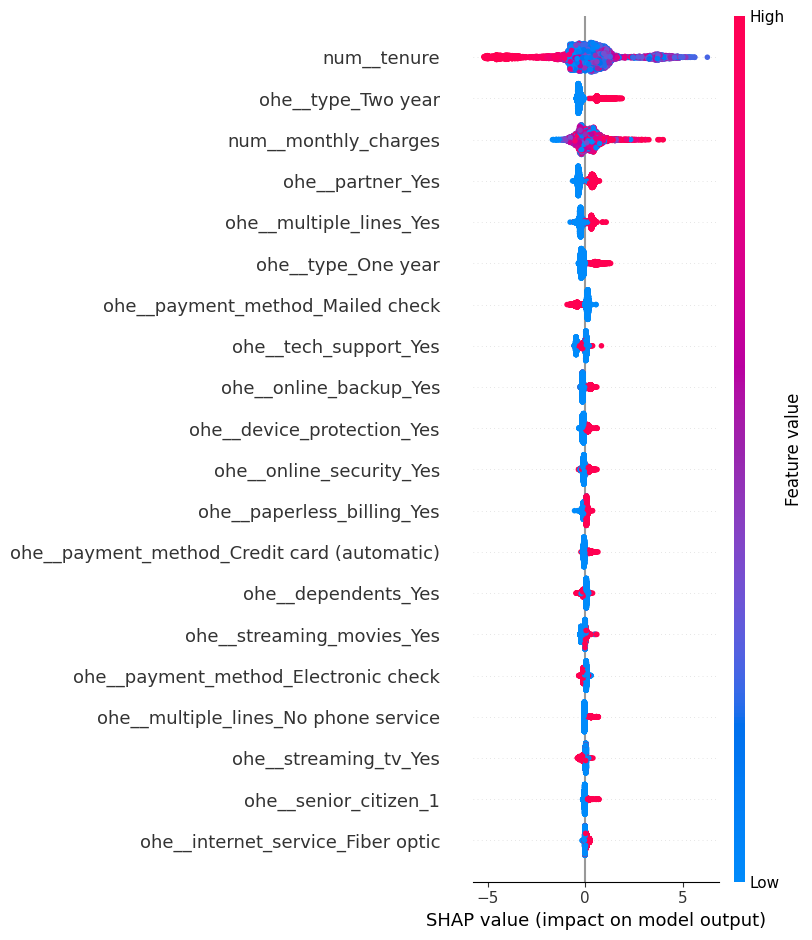

In [110]:
shap.summary_plot(shap_values, X_train_processed, feature_names=feature_names)


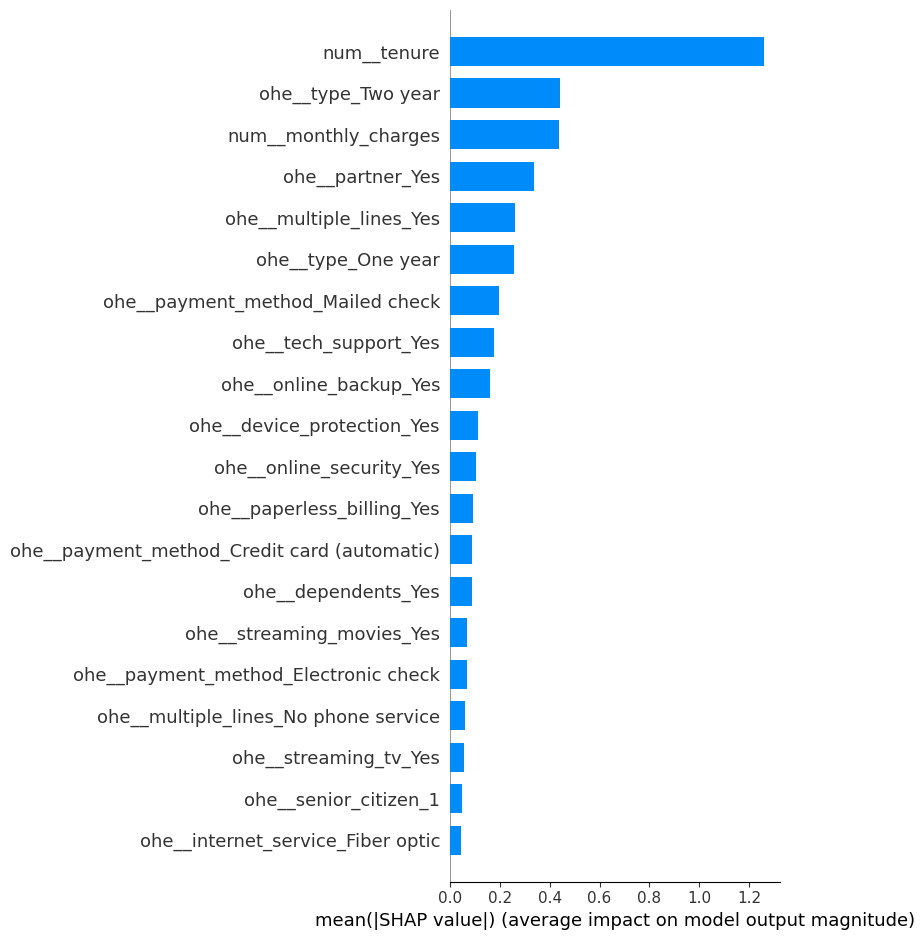

In [111]:
shap.summary_plot(shap_values, X_train_processed, feature_names=feature_names, plot_type="bar")

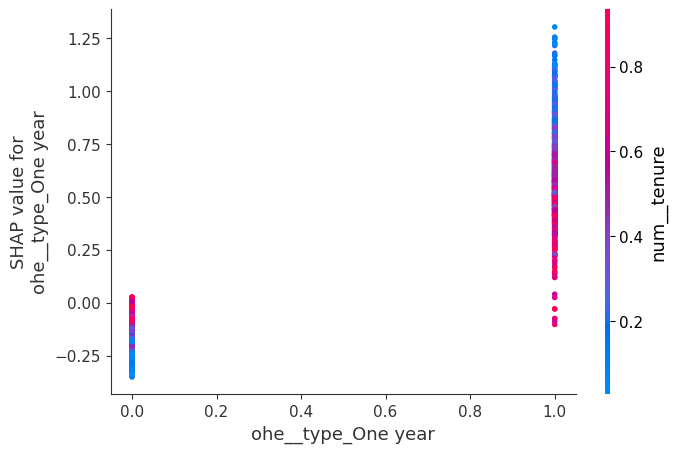

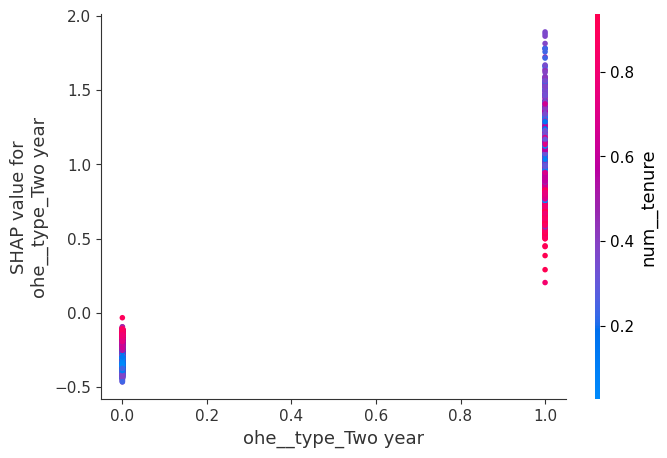

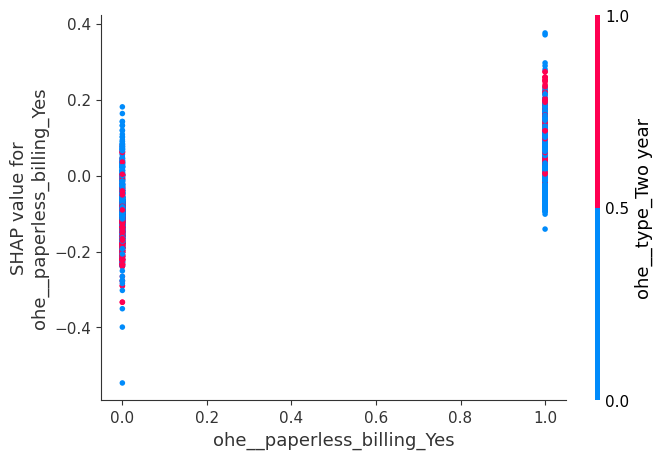

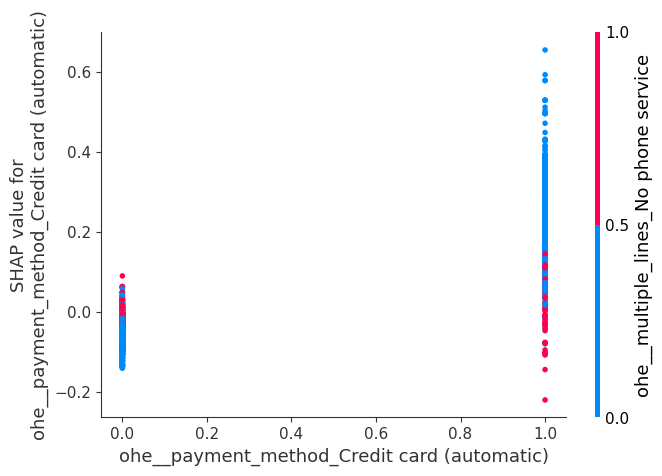

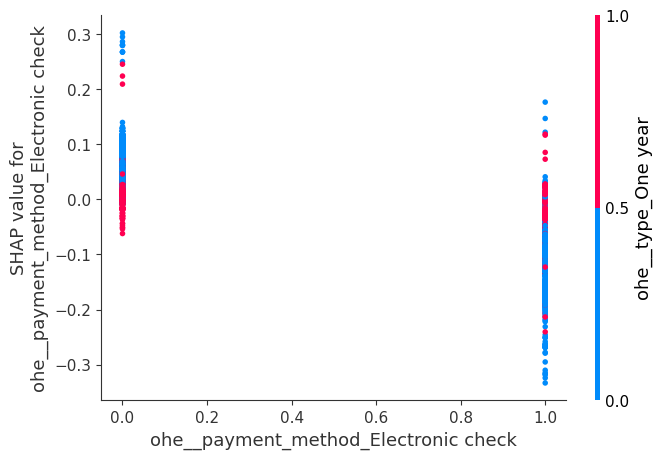

In [112]:
top_features = feature_names[:5]   # let's take the first 5

for f in top_features:
    shap.dependence_plot(f, shap_values, X_train_processed, feature_names=feature_names)


#### Conclusion on Shap analysis

1. Tenure is the most important retention factor.

Number_tenure is the number one key factor.

Low tenure (low values ​​→ red dots on the right) significantly increases the likelihood of churn.

Long tenure (long-term customers) results in a SHAP < 0, significantly reducing the risk of churn.

➡ New customers are the most vulnerable.
➡ A retention program should focus on them.

2. Monthly charges are the second most influential factor.

num__monthly_charges is also very significant:

High monthly charges increase SHAP → customers with expensive plans are more likely to churn.

Low charges reduce the risk of churn.

➡ The company primarily loses high-value customers.
➡ It makes sense to optimize plans or introduce personalized discounts.

3. Contract type is a critical retention indicator

Importance of indicators:

Month-to-month

ohe__type_Month-to-month is a strong driver of churn:

SHAP values ​​are generally > 0 → a monthly contract sharply increases churn.

Customers are not yet locked into a contract → quickly leave if dissatisfied or the price is high.

- One year

ohe__type_One year:

Has a slightly negative SHAP → moderately reduces churn.

But the effect is weaker than that of a two-year contract.

- Two year

ohe__type_Two year:

Significant SHAP < 0 → a two-year contract ensures better retention.

➡ Stability hierarchy:
Two years → One year → Month-to-month (high risk).

4. Impact of services and customer behavior
- Partner

ohe__partner_Yes reduces risk:

Family/busy customers are less likely to churn.

partner_No, on the contrary, increases churn.

- multiple_lines

ohe__multiple_lines_Yes:

Increases risk for a significant portion of customers.

Possibly: higher final cost → sensitivity to tariffs.

- Security and additional services

(tech_support_Yes, online_security_Yes, device_protection_Yes, online_backup_Yes)

All have moderately negative SHAPs.

Customers who purchase additional services are more loyal.

- billing & payment

paperless_billing_Yes, payment_method_Mailed check, Credit card, Bank transfer

The impact is weak, but there is a trend:

Automatic payments slightly reduce churn,

Paper receipts and electronic receipts are more common among more "unstable" clients.

5. Internet service is a secondary but logical factor.

- internet_service_Fiber optic:

Has a weak positive SHAP → slightly increases churn.

Fiber optic is usually more expensive → consistent with customers' high price sensitivity.

#### Class matrix

In [113]:
majority_class = y_test.mode()[0]
baseline_acc = (y_test == majority_class).mean()
display("Baseline accuracy (everything is as it is", majority_class, "):", baseline_acc)

'Baseline accuracy (все как'

0

'):'

0.8438387279954571

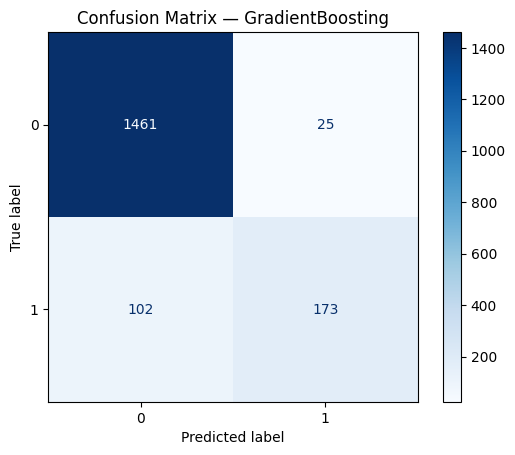

'Accuracy:'

0.9278818852924475

In [114]:
# Class Predictions
gb_y_test_pred = gb_pipe_best.predict(X_test)

# Error matrix
cm = confusion_matrix(y_test, gb_y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix — GradientBoosting")
plt.show()

# accuracy
display("Accuracy:", accuracy_score(y_test, gb_y_test_pred))


**Matrix output**

1. True Negative (TN) = 1461

The model correctly predicted that the customer would not churn.

This is an excellent result: the model generates almost no false alarms.
The retention department won't waste resources on stable customers.

2. False Positive (FP) = 25

The model incorrectly predicted that the customer would churn, but they would have stayed.

The FP is very low → the model is extremely cautious and hardly alerts loyal customers.

3. False Negative (FN) = 102

The model missed genuine churners and predicted "will stay."

! This is the main problem with the churn model:

the company loses the customer without even attempting to retain them.

FN = 102 is a significant volume, but not critical for a real business system.

4. True Positive (TP) = 173

The model correctly detected churners.

✔️ This means the model is truly useful: it catches a significant portion of churn customers.

**Matrix Metrics**
Accuracy: 0.9222

High accuracy because class 0 is so dominant.

- Recall (based on class 1 – ability to catch churn)

Recall = TP / (TP + FN)
Recall = 173 / 275 ≈ 0.63

The model catches 63% of churn customers.

- Precision (for churn)

Precision = TP / (TP + FP)
Precision = 173 / (173 + 25) ≈ 0.87

That is, 87% of those marked as churners by the model actually churn.

This is a very important quality indicator:
a business won't spend money on retaining those who stay anyway.

**Final Explanation**

1) The model is strong:

- excellent at distinguishing loyal customers (very high TN),

- virtually no false alarms (low FP),

- has a ROC-AUC of ≈ 0.93, which is close to the "excellent model" level,

- provides useful predictions for retention campaigns.

2) Main Problem:

The model misses some churners (FN = 102 → Recall ≈ 0.63).

This is normal for churn problems, where class 1 is rare:
models are often cautious and predict departures only with high confidence.

#### ROC curve

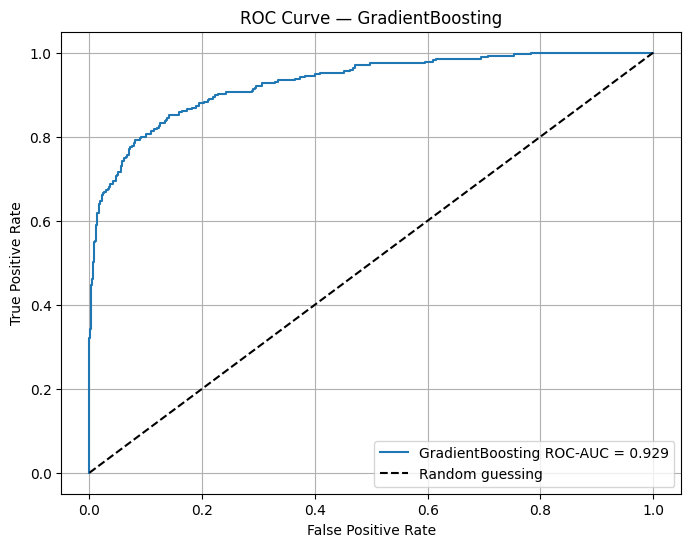

In [115]:
# Probability predictions
y_test_proba = gb_pipe_best.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'GradientBoosting ROC-AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'k--', label='Random guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — GradientBoosting')
plt.legend()
plt.grid(True)
plt.show()

#### ROC curve output


The ROC curve is significantly above the random guessing diagonal line. This means that the model distinguishes well between customers who will churn and those who will stay.

Key points:

1. Significant improvement over random guessing

The diagonal line is the "coin flip" level. Our curve is much higher, confirming the model's true ability to detect churn.

2. High sensitivity with a low false alarm rate

At low FPRs, the model already achieves a high True Positive Rate, indicating that it is able to catch churners while almost never mislabeling those who stay.

3. ROC-AUC = 0.929

The AUC value is close to 1.0, indicating very strong discriminatory power. The model confidently distinguishes between the two groups of users even when the classification threshold is changed.

4. Practical business implications

The model is capable of reliably generating a list of customers at risk of churn.

By choosing the right threshold, you can reduce lost customers (FN) without significantly increasing your FP.

Suitable for scenarios such as retention, personalized offers, trigger campaigns, and targeting.

## General conclusion and recommendations to the customer

The project included a full cycle of analytics and model development for predicting customer churn at a telecom company.
The work included stages from data analysis to model interpretation and the preparation of business recommendations.

### 1. Main stages of work

1.1. Data Collection and Merging

Several tables (contracts, clients, internet services, telephony) were loaded and merged, standardized, dates were processed correctly, and derived features, including tenure, were calculated. ✔️

1.2. Exploratory Data Analysis (EDA)

Distribution analysis was performed:

- a strong imbalance in the target variable was identified (≈15% churn);

- features for date, tariffs, and service availability were found to be important for customer behavior;

- missing and outliers were calculated, and numerical and categorical features were prepared.

1.3. Correlation Analysis (Phi-K)

The Phi-K method was used, allowing for the correct assessment of relationships between mixed data types. Important relationships were identified:

- tenure ↔ total_charges — ~0.98 (logically, service time determines the accumulated charge),

- type (Month-to-month) strongly correlates with churn — short-term customers churn more often.

1.4. Preprocessing via ColumnTransformer

Three groups of features were created:

- numeric (scaling),

- categorical (OneHotEncoding),

- binary/ordinal (OrdinalEncoder).

Omissions were processed, and categories were unified.

1.5. Model Building

Five models were trained:

- DecisionTreeClassifier
-
- LogisticRegression

- RandomForestClassifier

- GradientBoostingClassifier

- XGBoostClassifier

For each model, the following was performed:

1) Optuna hyperparameter tuning
2) StratifiedKFold cross-validation
3) ROC-AUC evaluation

GradientBoosting showed the best results.

### 2. Simulation results

Best Model: Gradient Boosting Classifier

Model Quality:

ROC-AUC (CV): 0.855

ROC-AUC (test): 0.929

Accuracy (test): 0.922

Confusion Matrix:

False Positives (FP) = 25
Customers were incorrectly marked as churning, although they would stay.
→ Very low number, almost no false alarms.

False Negatives (FN) = 102
The model did not detect any customers who actually churned.
→ Major risk (the model misses about 37.1% of churners).

True Positives (TP) = 173
The model correctly predicted churning.

True Negatives (TN) = 1461
The model correctly predicted no churning.

**ROC curve**

The model demonstrates a high ability to separate churners from retainers:

The curve lies significantly above the diagonal line.

ROC-AUC = 0.929 — the model has excellent separating power.

With a low FPR, the model maintains a high TPR → it catches churn well with minimal false positives.

**SHAP interpretation**

SHAP analysis revealed the key factors influencing the likelihood of churn.

Top risk factors:

1) Tenure — the strongest predictor

New customers (low tenure) churn frequently.

Long tenure dramatically reduces the likelihood of churn.

2) monthly_charges

High monthly payments increase the likelihood of churn.

3) type = Month-to-month

A short monthly contract is the most powerful churn trigger.

Customers without long-term commitments are more likely to churn.

4) Contract Type: One Year / Two Year

One year slightly reduces the risk.

Two years significantly protects against churn (strong retention factor).

5) multiple_lines, streaming, online_backup, tech_support, online_security

Secondary, but still important, indicators

The presence of a number of services indicates deeper engagement.

6) partner, dependents

The presence of a partner and dependents slightly reduces the likelihood of churn (more stable domestic customers).

- The SHAP interpretation fully confirms the business hypotheses:

New customer + high payments + monthly contract = maximum churn risk.

### 3. What does this mean for business?

3.1. The Main Risk: New Customers

SHAP showed that short tenure is the main driver of churn.
This means that churn is concentrated among customers in the first months of using the service.

3.2. Month-to-Month: The Most Volatile Segment

The month-to-month contract type had the strongest positive impact on churn.
Customers without long-term commitments churn the most.

3.3. High Service Costs Increase Risk

monthly_charges → The more expensive the plan, the higher the likelihood of churn.
Customers with high bills are more likely to switch to competitors.

3.4. Additional Services Partially Reduce Churn

The availability of online_backup, tech_support, streaming_tv, and other services provides a noticeable but moderate reduction in risk.
This means that a customer who has "invested" in the service ecosystem is less likely to churn.

3.5. Social factors are also important.

partner_Yes reduces the risk—SHAP showed stability among family clients.
senior_citizen (after correct coding)—a weak but logical risk factor.

### 4. Recommendations for business

4.1. New Client Retention (First 3-6 Months)

The main problem with this model is the FN (the model hasn't seen those leaving).
It's new clients who most often "drop out" of sight.

Recommended:

- Welcome period: discounts/bonus services for 1-3 months.

- Personalized support during the first weeks.

- Triggers at the first signs of dissatisfaction (increased support requests, reduced services).

4.2. Working with Month-to-Month Clients

This is the riskiest contract type.

Recommended:

- Offer upgrades to one year / two years with bonuses:

- discount,

- free equipment installation,

- free month.

- Limited "new clients only" promotions to encourage renewal.

4.3. Clients with high monthly fees

To reduce churn among the high-cost segment:

- Offer tariff recalculation/optimization,

- Bundle services (cheaper in one package than individually),

- Provide a benefit calculator → show the difference between plans.

4.4. Increasing the number of additional services

Data shows a moderate but stable retention effect from additional services.

Recommended:

- Bundle packages: "Streaming + Backup + Protection".

- First month free upon signing up for a package.

- Personalized offers based on consumption data.

4.5. Using the model in operational processes

The model can automatically:

- Generate "red lists" of high-risk clients;

- Run triggers: SMS, email, push;

- Transfer hot leads to the retention department;

- Monitor churn risk dynamics.

This will allow you to work with clients in a targeted manner, increasing the ROI of retention campaigns.